# Setup

## Imports

In [5]:
from pathlib import Path
import os
import pandas as pd
import sys
from matplotlib import pyplot as plt


import hatfield_funcs as hf

# project root = one level up from notebooks but potentially more from here
project_root = Path("../..").resolve()
sys.path.insert(0, str(project_root / "src"))

from biofilm_spectra.processing.spectral_matrix import to_spectral_matrix

from biofilm_spectra.processing.micasense import *
from my_extra_to_hatfield_funcs.io_funcs import *

In [6]:
plt.style.use("default")
%config InlineBackend.figure_format = 'retina'

In [7]:
CONTAINER_NAME = "wesa-fup-restricted-027817p"

if os.getenv("GA_STORAGE_ACCOUNT_NAME") is not None:
    # this is what gets used when using Azure cloud storage (GeoAnalytics)
    hf.config.configure_azure()
    hf.config.configure_data_root_path(CONTAINER_NAME)
else:
    # root path defined for local data
    raise Exception(
        "This notebook is configured to run in the cloud. Please set up your Azure storage account and container name."
    )
    hf.config.configure_data_root_path(
        r"C:\Users\username\Documents"
    )  # local data folder


## Parameters

In [8]:
SITES = ["brunswick", "westham"]

PIGMENT_LIST = [
    "Peri",
    "Chlc2",
    "Fuco",
    "Ddx",
    "Allo",
    "Myxo",
    "Lut",
    "Zea",
    "Cant",
    "Chlb",
    "Chl_allo1",
    "Chl_allo2",
    "Chla",
    "DVCh-a",
    "Echi",
    "Phtb",
    "Phta",
    "Acar",
    "Beta",
]
FA_LIST = [
    "C6",
    "C8",
    "C10",
    "C11",
    "C12",
    "C13",
    "C14-0",
    "C14-1",
    "C15",
    "C15-1",
    "C16",
    "C16-1",
    "C17:0",
    "C17:1",
    "C18:0",
    "C18:1N9T",
    "C18:1N9C",
    "C18:2N6T",
    "C18:2N6C",
    "C20:0",
    "C18:3N6",
    "C20:1N9",
    "C18:3N3",
    "C21:0",
    "C20:2",
    "C22:0",
    "C20:3N6",
    "C22:1N9",
    "C20:3N3",
    "C23:0",
    "C20:4N6",
    "C22:2",
    "C24:0",
    "C20:5N3",
    "C24:1N9",
    "C22:6N3",
]


In [9]:
# Input paths

# Lab data
path_lab_processed_folder = Path("data/processed/lab")
path_to_csv_clean_new_units = path_lab_processed_folder / "lab_data_clean_new_units.csv"
path_to_csv_clean_original_units = path_lab_processed_folder / "lab_data_clean_original_units.csv"

In [10]:
# Output path
path_output_dir = Path('./outputs/qaqc/')
path_output_dir.mkdir(parents=True, exist_ok=True)

# Read and complete/process data

In [11]:
# Lab data (read both original unit file and converted file to gather some of them)
df_lab_new = read_df_from_csv(path_to_csv_clean_new_units, index_col=[0, 1, 2])
df_lab_orig = read_df_from_csv(path_to_csv_clean_original_units, index_col=[0, 1, 2])

# We'll work on these 2 units for the pigments of interest
chla_columns_new_unit = 'mg/m2'
chla_columns_orig_unit = 'ppb'
chla_columns = ['Chla', 'Chl_allo1', 'Chl_allo2', 'DVCh-a', 'Phta']

# Add the full total
df_lab_new[f"Total Chla ({chla_columns_new_unit})"] = df_lab_new[[f"{x} ({chla_columns_new_unit})" for x in chla_columns]].sum(axis=1)
df_lab_orig[f"Total Chla ({chla_columns_orig_unit})"] = df_lab_orig[[f"{x} ({chla_columns_orig_unit})" for x in chla_columns]].sum(axis=1)

# Combine the chlorophyll a related columns
df_lab = df_lab_new.join(
    df_lab_orig[
        [f"{x} ({chla_columns_orig_unit})" for x in chla_columns + ["Total Chla"]]
    ],
    how="left",
)

# Define new total that do not take everything into account as a test:
# chla + dvch-a
# chla + dvch-a + allomers
dict_sum_chla_columns = {
    'Chla + DVCh-a': ['Chla', 'DVCh-a'],
    'Chla + DVCh-a + Allomers': ['Chla', 'DVCh-a', 'Chl_allo1', 'Chl_allo2']
}
# Apply sum for both units
for chla_unit in [chla_columns_new_unit, chla_columns_orig_unit]:
    for sum_name, sum_columns in dict_sum_chla_columns.items():
        df_lab[f"{sum_name} ({chla_unit})"] = df_lab[[f"{x} ({chla_unit})" for x in sum_columns]].sum(axis=1)

# Keep the total variants saved for later use
total_chla_column_base_names = []
for key in dict_sum_chla_columns.keys():
    total_chla_column_base_names.append(f"{key}")
total_chla_column_base_names.append('Total Chla')
total_chla_column_base_names

# Normalize index names so it's consistent with other dataframe (sorry for that! to be corrected earlier)
df_lab.index.names = [x.lower().replace(' ','_') for x in df_lab.index.names]

# Display first rows
df_lab.head()

Sample Total Dry Mass (g)  \
station_id round sample_type                              
B1         1     R                           124.920787   
           2     R                           102.318373   
B10        1     R                           113.372704   
           2     R                           135.840106   
B11        1     R                            68.488373   

                              Extraction Dry Mass (mg) Sample Date  \
station_id round sample_type                                         
B1         1     R                               554.2  2026-05-03   
           2     R                               512.4  2026-05-16   
B10        1     R                               460.8  2026-05-01   
           2     R                               582.7  2026-05-17   
B11        1     R                               480.4  2026-05-01   

                              Moisture (%)  Percent Sand (%)  \
station_id round sample_type                                   
B1         1     R               55.812630         91.182365   
           2     R               46.904693         73.170732   
B10        1     R               53.288243         73.684211   
           2     R                     NaN               NaN   
B11        1     R               60.344183         71.232877   

                              Percent Silt (%)  Percent Clay (%)  \
station_id round sample_type                                       
B1         1     R                    7.815631          1.002004   
           2     R                   26.829268          0.000000   
B10        1     R                   25.263158          1.052632   
           2     R                         NaN               NaN   
B11        1     R                   27.397260          1.369863   

                              Area Sampled (m2)  /g to /m2 conversion factor  \
station_id round sample_type                                                   
B1         1     R                        0.082                  1523.424232   
           2     R                        0.082                  1247.785032   
B10        1     R                        0.082                  1382.593955   
           2     R                        0.082                  1656.586662   
B11        1     R                        0.082                   835.224056   

                              Peri (mg/m2)  ...    Chla (ppb)  \
station_id round sample_type                ...                 
B1         1     R                0.197343  ...  12823.719671   
           2     R                0.258815  ...  22951.125365   
B10        1     R                0.219267  ...  15630.220854   
           2     R                0.359514  ...  14140.421516   
B11        1     R                0.069348  ...  14960.017487   

                              Chl_allo1 (ppb)  Chl_allo2 (ppb)  DVCh-a (ppb)  \
station_id round sample_type                                                   
B1         1     R                2101.932331       572.474304    791.537361   
           2     R                2938.555717       446.612320      0.000000   
B10        1     R                4321.023465       565.951487   2135.774587   
           2     R                3893.818711      1017.642452    718.932199   
B11        1     R                4737.947268       774.615388      0.000000   

                               Phta (ppb)  Total Chla (ppb)  \
station_id round sample_type                                  
B1         1     R            1006.600029      17296.263696   
           2     R             884.878313      27221.171715   
B10        1     R            1936.082122      24589.052514   
           2     R             783.806370      20554.621248   
B11        1     R            1072.427860      21545.008004   

                              Chla + DVCh-a (mg/m2)  \
station_id round sample_type                          
B1         1     R                        20.741812   
           2  

# Univariate QC

In [57]:
# Univariate QC
from dataclasses import dataclass
import numpy as np

@dataclass
class UnivariateQCResult:
    """Results from univariate concentration QC."""

    data: pd.DataFrame
    flags: pd.DataFrame
    z_scores: pd.DataFrame
    bounds: pd.DataFrame
    summary: pd.DataFrame
    issues: pd.DataFrame

def prepare_numeric_qc_data(
    df: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """Select and clean numeric columns for QC.

    Values that cannot be converted to numeric, as well as positive
    or negative infinity, are returned as missing values.

    Parameters
    ----------
    df
        Source dataframe. A regular Index or MultiIndex is supported.
    columns
        Columns to select.

    Returns
    -------
    pandas.DataFrame
        Numeric QC data with the original index retained.
    """
    if not columns:
        raise ValueError("At least one QC column must be supplied.")

    duplicate_columns = pd.Index(columns)[pd.Index(columns).duplicated()].unique()

    if len(duplicate_columns) > 0:
        raise ValueError(
            "Duplicate QC columns were supplied: "
            + ", ".join(map(str, duplicate_columns))
        )

    missing_columns = [column for column in columns if column not in df.columns]

    if missing_columns:
        raise KeyError(
            "The following QC columns are missing from the dataframe: "
            + ", ".join(missing_columns)
        )

    return (
        df.loc[:, columns]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

def flag_univariate_outliers(
    data: pd.DataFrame,
    *,
    z_threshold: float = 3.0,
    transform: str = "log10",
    min_reference_n: int = 8,
) -> UnivariateQCResult:
    """Flag deterministic issues and univariate statistical outliers.

    Outlier limits are calculated independently for each variable.
    By default, mean and standard deviation are calculated from the
    log10-transformed positive observations.

    Missing, zero, and negative values are identified separately and
    are excluded from the statistical reference distribution.

    Parameters
    ----------
    data
        Numeric dataframe containing the variables to assess.
    z_threshold
        Absolute z-score above which a value is flagged. A value of
        3.0 corresponds to mean plus or minus three standard deviations.
    transform
        Statistical scale. Supported options are:

        - ``"log10"``: recommended for right-skewed concentrations.
        - ``"raw"``: calculate mean and standard deviation directly.
    min_reference_n
        Minimum number of positive observations required to calculate
        statistical bounds for a variable.

    Returns
    -------
    UnivariateQCResult
        Clean data, cell flags, z-scores, bounds, summaries, and a
        long-form issue report.
    """
    if transform not in {"log10", "raw"}:
        raise ValueError("transform must be either 'log10' or 'raw'.")

    if z_threshold <= 0:
        raise ValueError("z_threshold must be greater than zero.")

    if min_reference_n < 3:
        raise ValueError("min_reference_n must be at least 3.")

    flags = pd.DataFrame(
        "ok",
        index=data.index,
        columns=data.columns,
        dtype="object",
    )

    z_scores = pd.DataFrame(
        np.nan,
        index=data.index,
        columns=data.columns,
        dtype="float64",
    )

    bounds_records = []
    summary_records = []
    issue_records = []

    for column in data.columns:
        values = data[column]

        missing_mask = values.isna()
        negative_mask = values.lt(0)
        zero_mask = values.eq(0)
        positive_mask = values.gt(0)

        flags.loc[missing_mask, column] = "missing"
        flags.loc[negative_mask, column] = "negative"
        flags.loc[zero_mask, column] = "zero"

        reference_values = values.loc[positive_mask]
        n_reference = len(reference_values)

        lower_bound = np.nan
        upper_bound = np.nan
        transformed_mean = np.nan
        transformed_std = np.nan
        bounds_status = "insufficient_reference_data"

        low_outlier_mask = pd.Series(
            False,
            index=data.index,
            dtype=bool,
        )

        high_outlier_mask = pd.Series(
            False,
            index=data.index,
            dtype=bool,
        )

        if n_reference >= min_reference_n:
            if transform == "log10":
                transformed_reference = np.log10(reference_values)
            else:
                transformed_reference = reference_values.copy()

            transformed_mean = transformed_reference.mean()
            transformed_std = transformed_reference.std(ddof=1)

            if pd.notna(transformed_std) and transformed_std > 0:
                transformed_lower = transformed_mean - z_threshold * transformed_std

                transformed_upper = transformed_mean + z_threshold * transformed_std

                if transform == "log10":
                    lower_bound = 10**transformed_lower
                    upper_bound = 10**transformed_upper

                    transformed_all = pd.Series(
                        np.nan,
                        index=data.index,
                        dtype="float64",
                    )

                    transformed_all.loc[positive_mask] = np.log10(
                        values.loc[positive_mask]
                    )
                else:
                    lower_bound = transformed_lower
                    upper_bound = transformed_upper
                    transformed_all = values.astype(float)

                column_z_scores = (transformed_all - transformed_mean) / transformed_std

                z_scores.loc[:, column] = column_z_scores

                low_outlier_mask = positive_mask & column_z_scores.lt(-z_threshold)

                high_outlier_mask = positive_mask & column_z_scores.gt(z_threshold)

                flags.loc[
                    low_outlier_mask,
                    column,
                ] = "low_outlier"

                flags.loc[
                    high_outlier_mask,
                    column,
                ] = "high_outlier"

                bounds_status = "calculated"

            else:
                bounds_status = "zero_reference_variance"

        bounds_records.append(
            {
                "variable": column,
                "transform": transform,
                "z_threshold": z_threshold,
                "n_reference": n_reference,
                "transformed_mean": transformed_mean,
                "transformed_std": transformed_std,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "status": bounds_status,
            }
        )

        summary_records.append(
            {
                "variable": column,
                "n_total": len(values),
                "n_missing": int(missing_mask.sum()),
                "n_negative": int(negative_mask.sum()),
                "n_zero": int(zero_mask.sum()),
                "n_positive": int(positive_mask.sum()),
                "positive_min": reference_values.min(),
                "positive_median": reference_values.median(),
                "positive_max": reference_values.max(),
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "n_low_outliers": int(low_outlier_mask.sum()),
                "n_high_outliers": int(high_outlier_mask.sum()),
            }
        )

        flag_definitions = {
            "missing": missing_mask,
            "negative": negative_mask,
            "zero": zero_mask,
            "low_outlier": low_outlier_mask,
            "high_outlier": high_outlier_mask,
        }

        for flag_name, flag_mask in flag_definitions.items():
            if not flag_mask.any():
                continue

            issue = pd.DataFrame(
                {
                    "variable": column,
                    "observed_value": values.loc[flag_mask],
                    "flag": flag_name,
                    "z_score": z_scores.loc[flag_mask, column],
                    "lower_bound": lower_bound,
                    "upper_bound": upper_bound,
                    "transform": transform,
                    "review_recommended": flag_name
                    in {
                        "negative",
                        "low_outlier",
                        "high_outlier",
                    },
                },
                index=values.index[flag_mask],
            )

            issue_records.append(issue)

    bounds = pd.DataFrame(bounds_records).set_index("variable")

    summary = pd.DataFrame(summary_records).set_index("variable")

    if issue_records:
        issues = pd.concat(issue_records)

        flag_priority = {
            "negative": 0,
            "high_outlier": 1,
            "low_outlier": 2,
            "zero": 3,
            "missing": 4,
        }

        issues["_flag_priority"] = issues["flag"].map(flag_priority).fillna(99)

        issues = issues.sort_values(
            ["_flag_priority", "variable", "z_score"],
            ascending=[True, True, False],
        ).drop(columns="_flag_priority")
    else:
        issues = pd.DataFrame(
            columns=[
                "variable",
                "observed_value",
                "flag",
                "z_score",
                "lower_bound",
                "upper_bound",
                "transform",
                "review_recommended",
            ]
        )

    return UnivariateQCResult(
        data=data,
        flags=flags,
        z_scores=z_scores,
        bounds=bounds,
        summary=summary,
        issues=issues,
    )

In [58]:
# Apply it to the original-unit pigment data

pigment_qc_columns_ppb = [
    f"{pigment} ({chla_columns_orig_unit})" for pigment in PIGMENT_LIST
]

pigment_data_ppb = prepare_numeric_qc_data(
    df_lab_orig,
    pigment_qc_columns_ppb,
)

pigment_univariate_qc = flag_univariate_outliers(
    pigment_data_ppb,
    z_threshold=3.0,
    transform="log10",
    min_reference_n=8,
)


In [59]:
display(
    pigment_univariate_qc.summary.style.format(
        {
            "positive_min": "{:.3g}",
            "positive_median": "{:.3g}",
            "positive_max": "{:.3g}",
            "lower_bound": "{:.3g}",
            "upper_bound": "{:.3g}",
        },
        na_rep="—",
    )
)


,n_total,n_missing,n_negative,n_zero,n_positive,positive_min,positive_median,positive_max,lower_bound,upper_bound,n_low_outliers,n_high_outliers
variable,,,,,,,,,,,,
Peri (ppb),140,0,0,9,131,1.06,145,735,8.36,1.74e+03,1,0
Chlc2 (ppb),140,0,0,6,134,37.3,146,795,17.3,1.32e+03,0,0
Fuco (ppb),140,0,0,0,140,668,3.55e+03,8.8e+03,1.24e+03,1.05e+04,1,0
Ddx (ppb),140,0,0,1,139,341,2.1e+03,7.43e+03,536,8.94e+03,2,0
Allo (ppb),140,0,0,1,139,12.7,156,1.03e+03,13.5,1.53e+03,1,0
Myxo (ppb),140,0,0,4,136,8.82,160,1.63e+03,12.3,1.7e+03,1,0
Lut (ppb),140,0,0,1,139,95.7,488,1.6e+03,103,2.24e+03,1,0
Zea (ppb),140,0,0,0,140,59.7,284,1.23e+03,38.9,1.83e+03,0,0
Cant (ppb),140,0,0,6,134,2.97,63.4,955,1.56,2.5e+03,0,0


In [60]:
potential_outliers = pigment_univariate_qc.issues.loc[
    pigment_univariate_qc.issues["flag"].isin(["low_outlier", "high_outlier"])
].copy()

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(potential_outliers)


,,,variable,observed_value,flag,z_score,lower_bound,upper_bound,transform,review_recommended
Station ID,Round,Sample Type,,,,,,,,
B24,1,R,Chl_allo2 (ppb),11383.766667,high_outlier,3.358868,29.654730,8136.637144,log10,True
B25,1,R,Chl_allo2 (ppb),8186.206525,high_outlier,3.006491,29.654730,8136.637144,log10,True
W23,1,R,Phta (ppb),6469.152803,high_outlier,3.403155,107.857495,4999.208943,log10,True
B22,1,R,Phtb (ppb),2800.260342,high_outlier,3.413587,29.735984,2088.854817,log10,True
B7,2,R,Allo (ppb),12.669603,low_outlier,-3.077683,13.470356,1531.567058,log10,True
B29,1,R,Chl_allo1 (ppb),19.441913,low_outlier,-4.657434,98.223521,34581.094838,log10,True
B28,1,R,Chla (ppb),74.776192,low_outlier,-6.168609,820.438038,76541.861894,log10,True
B29,1,R,Chla (ppb),64.940970,low_outlier,-6.355155,820.438038,76541.861894,log10,True
W23,1,R,DVCh-a (ppb),23.529207,low_outlier,-4.533416,64.393683,3308.831710,log10,True


In [61]:
pigment_univariate_qc_raw = flag_univariate_outliers(
    pigment_data_ppb,
    z_threshold=3.0,
    transform="raw",
    min_reference_n=8,
)

comparison = (
    pigment_univariate_qc.summary[
        [
            "lower_bound",
            "upper_bound",
            "n_low_outliers",
            "n_high_outliers",
        ]
    ]
    .add_prefix("log10_")
    .join(
        pigment_univariate_qc_raw.summary[
            [
                "lower_bound",
                "upper_bound",
                "n_low_outliers",
                "n_high_outliers",
            ]
        ].add_prefix("raw_")
    )
)

display(comparison)


,log10_lower_bound,log10_upper_bound,log10_n_low_outliers,log10_n_high_outliers,raw_lower_bound,raw_upper_bound,raw_n_low_outliers,raw_n_high_outliers
variable,,,,,,,,
Peri (ppb),8.356117,1743.989633,1,0,-204.696619,531.430488,0,3
Chlc2 (ppb),17.336460,1323.581853,0,0,-256.455708,649.300808,0,2
Fuco (ppb),1244.395039,10456.165708,1,0,-129.533010,7785.511613,0,1
Ddx (ppb),535.837771,8943.775042,2,0,-899.717399,5751.924128,0,1
Allo (ppb),13.470356,1531.567058,1,0,-241.920012,616.764812,0,3
Myxo (ppb),12.277767,1696.071314,1,0,-351.295950,741.910518,0,2
Lut (ppb),103.413474,2241.045627,1,0,-279.802171,1369.893937,0,1
Zea (ppb),38.942947,1830.884709,0,0,-317.274786,969.883642,0,1
Cant (ppb),1.564666,2502.202241,0,0,-345.763308,591.147357,0,4


In [62]:
from dataclasses import dataclass

import numpy as np
import pandas as pd


@dataclass
class NonDetectContextResult:
    """Contextual information about reported non-detects."""

    report: pd.DataFrame
    sample_summary: pd.DataFrame
    quantifiable_thresholds: pd.Series

def assess_non_detect_context(
    data: pd.DataFrame,
    *,
    detection_limit: float = 10.0,
    high_quantile: float = 0.75,
) -> NonDetectContextResult:
    """Assess reported non-detects using other variables in the sample.

    A value of zero is interpreted as a reported non-detect. The
    function does not declare a non-detect incorrect. Instead, it
    identifies non-detects occurring alongside elevated values of
    other variables.

    Parameters
    ----------
    data
        Numeric dataframe containing related concentration variables.
    detection_limit
        Minimum detectable or reportable concentration.
    high_quantile
        Quantile of quantifiable values used to define an elevated
        concentration for each variable.

    Returns
    -------
    NonDetectContextResult
        Long-form non-detect report, sample summary, and the
        variable-specific high-concentration thresholds.
    """
    if detection_limit <= 0:
        raise ValueError("detection_limit must be greater than zero.")

    if not 0 < high_quantile < 1:
        raise ValueError("high_quantile must be between zero and one.")

    numeric_data = data.apply(pd.to_numeric, errors="coerce").replace(
        [np.inf, -np.inf], np.nan
    )

    non_detect_mask = numeric_data.eq(0)
    quantifiable_mask = numeric_data.ge(detection_limit)

    # Calculate each variable's high-value threshold using only
    # quantifiable observations.
    quantifiable_data = numeric_data.where(quantifiable_mask)

    high_thresholds = quantifiable_data.quantile(high_quantile)

    high_value_mask = quantifiable_data.ge(
        high_thresholds,
        axis="columns",
    )

    sample_summary = pd.DataFrame(
        {
            "n_non_detect": non_detect_mask.sum(axis=1),
            "n_quantifiable": quantifiable_mask.sum(axis=1),
            "n_high": high_value_mask.sum(axis=1),
            "all_non_detect": non_detect_mask.all(axis=1),
        },
        index=numeric_data.index,
    )

    sample_summary["non_detect_variables"] = non_detect_mask.apply(
        lambda row: ", ".join(
            column for column, is_non_detect in row.items() if is_non_detect
        ),
        axis=1,
    )

    sample_summary["quantifiable_variables"] = quantifiable_mask.apply(
        lambda row: ", ".join(
            column for column, is_quantifiable in row.items() if is_quantifiable
        ),
        axis=1,
    )

    sample_summary["high_variables"] = high_value_mask.apply(
        lambda row: ", ".join(column for column, is_high in row.items() if is_high),
        axis=1,
    )

    report_parts = []

    for target in numeric_data.columns:
        target_non_detect = non_detect_mask[target]

        if not target_non_detect.any():
            continue

        other_columns = [column for column in numeric_data.columns if column != target]

        other_values = numeric_data.loc[
            target_non_detect,
            other_columns,
        ]

        other_quantifiable = quantifiable_mask.loc[
            target_non_detect,
            other_columns,
        ]

        other_high = high_value_mask.loc[
            target_non_detect,
            other_columns,
        ]

        n_other_quantifiable = other_quantifiable.sum(axis=1)
        n_other_high = other_high.sum(axis=1)

        maximum_other_value = other_values.max(axis=1)
        sum_other_quantifiable = other_values.where(other_quantifiable).sum(
            axis=1, min_count=1
        )

        context_class = np.select(
            [
                n_other_high.ge(2),
                n_other_high.eq(1),
                n_other_quantifiable.gt(0),
            ],
            [
                "non_detect_with_multiple_high_related_values",
                "non_detect_with_one_high_related_value",
                "non_detect_with_other_quantifiable_values",
            ],
            default="non_detect_with_no_other_quantifiable_values",
        )

        review_priority = np.select(
            [
                n_other_high.ge(2),
                n_other_high.eq(1),
                n_other_quantifiable.gt(0),
            ],
            [
                "high",
                "medium",
                "low",
            ],
            default="informational",
        )

        target_report = pd.DataFrame(
            {
                "variable": target,
                "reported_value": 0.0,
                "interpretation": (
                    f"Non-detect; assumed concentration ≤ {detection_limit:g}"
                ),
                "n_other_quantifiable": n_other_quantifiable,
                "n_other_high": n_other_high,
                "maximum_other_value": maximum_other_value,
                "sum_other_quantifiable": sum_other_quantifiable,
                "high_other_variables": other_high.apply(
                    lambda row: ", ".join(
                        column for column, is_high in row.items() if is_high
                    ),
                    axis=1,
                ),
                "context_class": context_class,
                "review_priority": review_priority,
            },
            index=other_values.index,
        )

        report_parts.append(target_report)

    if report_parts:
        report = pd.concat(report_parts)

        priority_order = {
            "high": 0,
            "medium": 1,
            "low": 2,
            "informational": 3,
        }

        report["_priority"] = report["review_priority"].map(priority_order).fillna(99)

        report = report.sort_values(
            [
                "_priority",
                "n_other_high",
                "maximum_other_value",
            ],
            ascending=[True, False, False],
        ).drop(columns="_priority")
    else:
        report = pd.DataFrame()

    return NonDetectContextResult(
        report=report,
        sample_summary=sample_summary,
        quantifiable_thresholds=high_thresholds,
    )

In [63]:
non_detect_context = assess_non_detect_context(
    pigment_data_ppb,
    detection_limit=10.0,
    high_quantile=0.75,
)

display(
    non_detect_context.quantifiable_thresholds.rename(
        "75th percentile of quantifiable values"
    ).to_frame()
)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(non_detect_context.report)

priority_non_detects = non_detect_context.report.loc[
    non_detect_context.report["review_priority"].isin(["high", "medium"])
]

display(priority_non_detects)

,75th percentile of quantifiable values
Peri (ppb),215.108107
Chlc2 (ppb),263.000980
Fuco (ppb),4633.905757
Ddx (ppb),3093.156021
Allo (ppb),229.512347
Myxo (ppb),229.441186
Lut (ppb),706.027479
Zea (ppb),414.041939
Cant (ppb),165.299126
Chlb (ppb),265.706320


variable  reported_value  \
Station ID Round Sample Type                                    
B16        1     R                 Beta (ppb)             0.0   
B25        2     R               DVCh-a (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
B16        2     R                 Beta (ppb)             0.0   
B11        1     R               DVCh-a (ppb)             0.0   
B10        1     R                 Beta (ppb)             0.0   
B9         1     R                 Beta (ppb)             0.0   
B17        2     R                 Beta (ppb)             0.0   
B19        2     R                 Beta (ppb)             0.0   
B24        1     R                 Myxo (ppb)             0.0   
                 R                 Acar (ppb)             0.0   
B20        1     R            Chl_allo2 (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
B29        2     R               DVCh-a (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
W26        2     R                 Beta (ppb)             0.0   
W25        2     R                 Beta (ppb)             0.0   
B23        1     R                 Beta (ppb)             0.0   
W29        2     S                 Beta (ppb)             0.0   
B18        1     R                 Acar (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
B21        1     R                 Phtb (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
W29        1     R                 Beta (ppb)             0.0   
B10        2     R                 Beta (ppb)             0.0   
B17        1     R                 Phtb (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
B18        2     R                 Beta (ppb)             0.0   
B9         2     S                 Beta (ppb)             0.0   
B2         1     R                 Phtb (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
W28        2     S                 Beta (ppb)             0.0   
B9         2     R                 Beta (ppb)             0.0   
B11        2     R                 Beta (ppb)             0.0   
B1         1     R                 Beta (ppb)             0.0   
B25        1     R                Chlc2 (ppb)             0.0   
                 R                 Myxo (ppb)             0.0   
                 R                 Echi (ppb)             0.0   
                 R                 Phta (ppb)             0.0   
                 R                 Acar (ppb)             0.0   
B1         2     R               DVCh-a (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
W28        2     R                 Beta (ppb)             0.0   
W24        2     R                 Beta (ppb)             0.0   
B16        2     S                 Beta (ppb)             0.0   
B26        1     R                Chlc2 (ppb)             0.0   
                 R                 Myxo (ppb)             0.0   
                 R                 Phtb (ppb)             0.0   
                 R                 Phta (ppb)             0.0   
                 R                 Acar (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
B24        2     R               DVCh-a (ppb)             0.0   
                 R                 Beta (ppb)             0.0   
B25        2     S               DVCh-a (ppb)             0.0   
                 S                 Beta (ppb)             0.0   
W10        1     R                 Beta (ppb)             0.0   
B3         1     R                 Beta (ppb)             0.0   
W25        2     S                 Beta (ppb)             0.0   
B27        1     R                 Phtb (ppb)             0.0   
                 R                 Acar (ppb)             0.0   
       

variable  reported_value  \
Station ID Round Sample Type                                 
B16        1     R              Beta (ppb)             0.0   
B25        2     R            DVCh-a (ppb)             0.0   
                 R              Beta (ppb)             0.0   
B16        2     R              Beta (ppb)             0.0   
B11        1     R            DVCh-a (ppb)             0.0   
...                                    ...             ...   
B7         2     R              Beta (ppb)             0.0   
W5         1     R              Beta (ppb)             0.0   
B22        2     R              Beta (ppb)             0.0   
B6         1     R              Phtb (ppb)             0.0   
                 R              Beta (ppb)             0.0   

                                                      interpretation  \
Station ID Round Sample Type                                           
B16        1     R            Non-detect; assumed concentration ≤ 10   
B25        2     R            Non-detect; assumed concentration ≤ 10   
                 R            Non-detect; assumed concentration ≤ 10   
B16        2     R            Non-detect; assumed concentration ≤ 10   
B11        1     R            Non-detect; assumed concentration ≤ 10   
...                                                              ...   
B7         2     R            Non-detect; assumed concentration ≤ 10   
W5         1     R            Non-detect; assumed concentration ≤ 10   
B22        2     R            Non-detect; assumed concentration ≤ 10   
B6         1     R            Non-detect; assumed concentration ≤ 10   
                 R            Non-detect; assumed concentration ≤ 10   

                              n_other_quantifiable  n_other_high  \
Station ID Round Sample Type                                       
B16        1     R                              18            16   
B25        2     R                              17            16   
                 R                              17            16   
B16        2     R                              18            16   
B11        1     R                              18            15   
...                                            ...           ...   
B7         2     R                              15             1   
W5         1     R                              18             1   
B22        2     R                              17             1   
B6         1     R                              17             1   
                 R                              17             1   

                              maximum_other_value  sum_other_quantifiable  \
Station ID Round Sample Type                                                
B16        1     R                   23221.894288            47564.034130   
B25        2     R                   16561.777177            50182.265063   
                 R                   16561.777177            50182.265063   
B16        2     R                   12540.788169            35512.620474   
B11        1     R                   14960.017487            36931.777372   
...                                           ...                     ...   
B7         2     R                    5911.822863            10882.291714   
W5         1     R                    5547.049271            13390.717962   
B22        2     R                    5224.658116            17503.965823   
B6         1     R                    5168.635824            15059.746788   
                 R                    5168.635824            15059.746788   

                                                           high_other_variables  \
Station ID Round Sample Type                                                      
B16        1     R            Peri (ppb), Chlc2 (ppb), Fuco (ppb), Ddx (ppb)...   
B25        2     R            Peri (ppb), Chlc2 (ppb), Fuco (ppb), Ddx (ppb)...   
                 R            Peri (ppb), Chlc2 (ppb), Fuco (ppb), Ddx 

In [64]:
len(PIGMENT_LIST)

19

In [65]:
# ============================================================
# INTERNAL CONSISTENCY ASSESSMENT OF PIGMENT NON-DETECTS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.pipeline import Pipeline


def analyze_pigment_non_detects(
    df,
    pigment_base_names,
    *,
    unit="ppb",
    detection_limit=10.0,
    non_detect_replacement=None,
    # context_high_quantile=0.75,
    context_high_quantile=0.90,
    group_level="station_id",
    confidence=0.95,
    min_training_rows=20,
    minimum_model_r2=0.50,
    minimum_expected_multiple=2.0,
    n_estimators=300,
    random_state=42,
):
    """Assess whether reported pigment non-detects are internally consistent.

    A reported value of zero is interpreted as a censored non-detect,
    meaning that the true concentration is assumed to be less than or
    equal to the detection/reporting limit.

    For each pigment, this function:

    1. Identifies missing, negative, non-detect, below-limit, and
       quantifiable observations.
    2. Describes the concentrations of all other pigments in samples
       containing a non-detect.
    3. Fits a cross-validated random-forest model using the other
       pigments to predict the target pigment.
    4. Flags a non-detect only when:
       - the model has adequate cross-validated performance;
       - the conservative prediction lower bound exceeds the detection
         limit; and
       - the central prediction is materially above the detection limit.

    Parameters
    ----------
    df : pandas.DataFrame
        Source laboratory dataframe. A MultiIndex is supported.
    pigment_base_names : sequence of str
        Pigment names without unit suffixes.
    unit : str
        Unit included in the dataframe column names.
    detection_limit : float
        Detection or reporting limit applied to all pigments.
    non_detect_replacement : float, optional
        Numerical value used for non-detect predictor values. Defaults
        to half the detection limit. This does not modify the original
        reported data.
    context_high_quantile : float
        Quantile of quantifiable observations used to define a high
        value for the transparent within-sample context check.
    group_level : str or None
        Index level used for grouped cross-validation. Matching is
        insensitive to capitalization, spaces, hyphens, and underscores.
    confidence : float
        Quantile of cross-validated absolute errors used to construct
        approximate prediction limits.
    min_training_rows : int
        Minimum number of quantifiable target observations required.
    minimum_model_r2 : float
        Minimum cross-validated R-squared required for a lab-facing flag.
    minimum_expected_multiple : float
        Central model prediction must exceed this multiple of the
        detection limit before a non-detect can receive a strict flag.
    n_estimators : int
        Number of trees in each random-forest model.
    random_state : int
        Random seed.

    Returns
    -------
    dict
        Dictionary containing cleaned data, summaries, non-detect
        assessments, model diagnostics, reporting issues, internal-review
        candidates, strict lab-review candidates, and fitted models.
    """
    if detection_limit <= 0:
        raise ValueError("detection_limit must be greater than zero.")

    if not 0 < context_high_quantile < 1:
        raise ValueError("context_high_quantile must be between zero and one.")

    if not 0 < confidence < 1:
        raise ValueError("confidence must be between zero and one.")

    if minimum_expected_multiple < 1:
        raise ValueError("minimum_expected_multiple must be at least 1.")

    if non_detect_replacement is None:
        non_detect_replacement = detection_limit / 2

    pigment_columns = [f"{pigment} ({unit})" for pigment in pigment_base_names]

    missing_columns = [column for column in pigment_columns if column not in df.columns]

    if missing_columns:
        raise KeyError(
            "The following pigment columns are missing from the "
            "source dataframe:\n- " + "\n- ".join(missing_columns)
        )

    # --------------------------------------------------------
    # Prepare numeric data
    # --------------------------------------------------------

    data = (
        df.loc[:, pigment_columns]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

    missing_mask = data.isna()
    negative_mask = data.lt(0)

    # A reported zero represents a non-detect, not a measured zero.
    non_detect_mask = data.eq(0)

    # These values conflict with the assumed reporting convention.
    below_detection_mask = data.gt(0) & data.lt(detection_limit)

    quantifiable_mask = data.ge(detection_limit)

    # Variable-specific thresholds defining relatively high values.
    quantifiable_data = data.where(quantifiable_mask)

    high_thresholds = quantifiable_data.quantile(context_high_quantile)

    high_value_mask = quantifiable_data.ge(
        high_thresholds,
        axis="columns",
    )

    # --------------------------------------------------------
    # Resolve the requested group level
    # --------------------------------------------------------

    def normalize_name(value):
        if value is None:
            return None

        return str(value).strip().lower().replace(" ", "_").replace("-", "_")

    resolved_group_level = None

    if group_level is not None:
        requested_group_name = normalize_name(group_level)

        for existing_name in data.index.names:
            if normalize_name(existing_name) == requested_group_name:
                resolved_group_level = existing_name
                break

    # --------------------------------------------------------
    # Overall summary
    # --------------------------------------------------------

    summary_records = []

    for column in pigment_columns:
        quantifiable_values = data.loc[
            quantifiable_mask[column],
            column,
        ]

        summary_records.append(
            {
                "pigment": column,
                "n_total": len(data),
                "n_missing": int(missing_mask[column].sum()),
                "n_negative": int(negative_mask[column].sum()),
                "n_non_detect": int(non_detect_mask[column].sum()),
                "non_detect_percent": (100 * non_detect_mask[column].mean()),
                "n_positive_below_detection": int(below_detection_mask[column].sum()),
                "n_quantifiable": int(quantifiable_mask[column].sum()),
                "quantifiable_min": quantifiable_values.min(),
                "quantifiable_median": quantifiable_values.median(),
                "quantifiable_max": quantifiable_values.max(),
                "high_context_threshold": high_thresholds[column],
            }
        )

    pigment_summary = pd.DataFrame(summary_records).set_index("pigment")

    # --------------------------------------------------------
    # Create a long report of reporting-rule issues
    # --------------------------------------------------------

    reporting_issue_parts = []

    issue_definitions = [
        (
            "missing",
            missing_mask,
            "medium",
            "No laboratory result was reported.",
        ),
        (
            "negative",
            negative_mask,
            "critical",
            "Negative concentration; laboratory review recommended.",
        ),
        (
            "positive_below_detection",
            below_detection_mask,
            "high",
            (
                f"Positive value is below the assumed reporting limit "
                f"of {detection_limit:g} {unit}; verify the reporting "
                "and non-detect convention."
            ),
        ),
    ]

    for issue_type, issue_mask, severity, reason in issue_definitions:
        for column in pigment_columns:
            column_mask = issue_mask[column]

            if not column_mask.any():
                continue

            issue_report = pd.DataFrame(
                {
                    "pigment": column,
                    "observed_value": data.loc[
                        column_mask,
                        column,
                    ],
                    "issue_type": issue_type,
                    "severity": severity,
                    "reason": reason,
                },
                index=data.index[column_mask],
            )

            reporting_issue_parts.append(issue_report)

    if reporting_issue_parts:
        reporting_issues = pd.concat(reporting_issue_parts)
    else:
        reporting_issues = pd.DataFrame(
            columns=[
                "pigment",
                "observed_value",
                "issue_type",
                "severity",
                "reason",
            ]
        )

    # --------------------------------------------------------
    # Prepare predictor data
    # --------------------------------------------------------

    # Negative concentrations are invalid and are treated as missing.
    model_features = data.mask(data.lt(0))

    # For model predictors only, represent censored values using half
    # the detection limit. The original reported data remain unchanged.
    censored_predictors = model_features.notna() & model_features.lt(detection_limit)

    model_features = model_features.mask(
        censored_predictors,
        non_detect_replacement,
    )

    # --------------------------------------------------------
    # Helper functions for modelling
    # --------------------------------------------------------

    def create_model():
        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median",
                        add_indicator=True,
                    ),
                ),
                (
                    "regressor",
                    RandomForestRegressor(
                        n_estimators=n_estimators,
                        min_samples_leaf=2,
                        max_features=0.8,
                        n_jobs=1,
                        random_state=random_state,
                    ),
                ),
            ]
        )

    def choose_cross_validation(X):
        if resolved_group_level is not None:
            groups = X.index.get_level_values(resolved_group_level)

            n_groups = groups.nunique()

            if n_groups >= 3:
                n_splits = min(5, n_groups)

                return (
                    GroupKFold(n_splits=n_splits),
                    groups,
                    f"GroupKFold({n_splits})",
                )

        n_splits = min(5, len(X))

        if n_splits < 2:
            return None, None, None

        return (
            KFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=random_state,
            ),
            None,
            f"KFold({n_splits})",
        )

    # --------------------------------------------------------
    # Assess non-detects for each target pigment
    # --------------------------------------------------------

    non_detect_report_parts = []
    model_summary_records = []
    fitted_models = {}

    for target in pigment_columns:
        target_values = data[target]

        target_non_detect = target_values.eq(0)
        target_training = target_values.ge(detection_limit)

        n_non_detect = int(target_non_detect.sum())
        n_training = int(target_training.sum())

        predictors = [column for column in pigment_columns if column != target]

        model_summary = {
            "pigment": target,
            "status": "Not evaluated",
            "n_training": n_training,
            "n_non_detect": n_non_detect,
            "n_predictors": len(predictors),
            "cv_method": np.nan,
            "cv_r2_log": np.nan,
            "cv_mae_original_units": np.nan,
            "error_quantile_log": np.nan,
            "model_reliable": False,
            "n_outside_normal_model_error": 0,
            "n_model_suggests_unexpected": 0,
            "n_unexpected_non_detect": 0,
        }

        # ----------------------------------------------------
        # Transparent within-sample context
        # ----------------------------------------------------

        if n_non_detect > 0:
            other_values = data.loc[
                target_non_detect,
                predictors,
            ]

            other_quantifiable = quantifiable_mask.loc[
                target_non_detect,
                predictors,
            ]

            other_high = high_value_mask.loc[
                target_non_detect,
                predictors,
            ]

            n_other_quantifiable = other_quantifiable.sum(axis=1)
            n_other_high = other_high.sum(axis=1)

            maximum_other_value = other_values.max(axis=1)

            sum_other_quantifiable = other_values.where(other_quantifiable).sum(
                axis=1, min_count=1
            )

            context_class = np.select(
                [
                    n_other_high.ge(2),
                    n_other_high.eq(1),
                    n_other_quantifiable.gt(0),
                ],
                [
                    "non_detect_with_multiple_high_pigments",
                    "non_detect_with_one_high_pigment",
                    "non_detect_with_other_quantifiable_pigments",
                ],
                default=("non_detect_with_no_other_quantifiable_pigments"),
            )

            context_priority = np.select(
                [
                    n_other_high.ge(2),
                    n_other_high.eq(1),
                    n_other_quantifiable.gt(0),
                ],
                [
                    "medium",
                    "low",
                    "informational",
                ],
                default="informational",
            )

            target_report = pd.DataFrame(
                {
                    "pigment": target,
                    "reported_value": 0.0,
                    "interpretation": (
                        f"Reported non-detect; assumed ≤ {detection_limit:g} {unit}"
                    ),
                    "n_other_quantifiable": n_other_quantifiable,
                    "n_other_high": n_other_high,
                    "maximum_other_value": maximum_other_value,
                    "sum_other_quantifiable": (sum_other_quantifiable),
                    "high_other_pigments": other_high.apply(
                        lambda row: ", ".join(
                            pigment for pigment, is_high in row.items() if is_high
                        ),
                        axis=1,
                    ),
                    "context_class": context_class,
                    "context_priority": context_priority,
                    "model_status": "Not evaluated",
                    "predicted_value": np.nan,
                    "prediction_lower": np.nan,
                    "prediction_upper": np.nan,
                    "anomaly_percentile": np.nan,
                    "outside_normal_model_error": False,
                    "model_cv_r2_log": np.nan,
                    "model_cv_mae": np.nan,
                    "model_is_reliable": False,
                    "model_suggests_unexpected": False,
                    "materially_above_detection": False,
                    "unexpected_non_detect": False,
                },
                index=other_values.index,
            )
        else:
            target_report = None
            model_summary["status"] = "No non-detects to assess"

        # ----------------------------------------------------
        # Model-based internal consistency assessment
        # ----------------------------------------------------

        if n_non_detect == 0:
            model_summary_records.append(model_summary)
            continue

        if n_training < min_training_rows:
            model_summary["status"] = "Insufficient quantifiable training data"

            target_report["model_status"] = "Insufficient quantifiable training data"

            non_detect_report_parts.append(target_report)
            model_summary_records.append(model_summary)
            continue

        if target_values.loc[target_training].nunique() < 2:
            model_summary["status"] = "Target has no usable variation"

            target_report["model_status"] = "Target has no usable variation"

            non_detect_report_parts.append(target_report)
            model_summary_records.append(model_summary)
            continue

        X_train_all = model_features.loc[
            target_training,
            predictors,
        ]

        # Remove predictors containing no usable training information.
        usable_predictors = [
            column for column in predictors if X_train_all[column].notna().any()
        ]

        if not usable_predictors:
            model_summary["status"] = "No usable predictors"
            model_summary["n_predictors"] = 0
            target_report["model_status"] = "No usable predictors"

            non_detect_report_parts.append(target_report)
            model_summary_records.append(model_summary)
            continue

        X_train = X_train_all.loc[:, usable_predictors]

        y_train_original = target_values.loc[target_training]

        # Model concentrations on a log scale.
        y_train_log = np.log1p(y_train_original.to_numpy())

        cv, groups, cv_name = choose_cross_validation(X_train)

        if cv is None:
            model_summary["status"] = "Not enough observations for cross-validation"

            target_report["model_status"] = (
                "Not enough observations for cross-validation"
            )

            non_detect_report_parts.append(target_report)
            model_summary_records.append(model_summary)
            continue

        model = create_model()

        cv_kwargs = {
            "estimator": model,
            "X": X_train,
            "y": y_train_log,
            "cv": cv,
            "n_jobs": -1,
            "method": "predict",
        }

        if groups is not None:
            cv_kwargs["groups"] = groups

        try:
            oof_prediction_log = cross_val_predict(**cv_kwargs)

            oof_absolute_error = np.abs(y_train_log - oof_prediction_log)

            error_quantile = np.quantile(
                oof_absolute_error,
                confidence,
            )

            cv_r2_log = r2_score(
                y_train_log,
                oof_prediction_log,
            )

            oof_prediction_original = np.maximum(
                0,
                np.expm1(oof_prediction_log),
            )

            cv_mae = mean_absolute_error(
                y_train_original,
                oof_prediction_original,
            )

            model_is_reliable = np.isfinite(cv_r2_log) and cv_r2_log >= minimum_model_r2

            # Fit the final model using all quantifiable target values.
            model.fit(
                X_train,
                y_train_log,
            )

            fitted_models[target] = model

            X_non_detect = model_features.loc[
                target_non_detect,
                usable_predictors,
            ]

            predicted_log = model.predict(X_non_detect)

            predicted_value = np.maximum(
                0,
                np.expm1(predicted_log),
            )

            prediction_lower = np.maximum(
                0,
                np.expm1(predicted_log - error_quantile),
            )

            prediction_upper = np.maximum(
                0,
                np.expm1(predicted_log + error_quantile),
            )

            # Observed non-detect is represented as log1p(0) = 0.
            non_detect_error_log = np.abs(predicted_log)

            outside_normal_model_error = non_detect_error_log > error_quantile

            anomaly_percentile = np.array(
                [
                    100 * np.mean(oof_absolute_error <= candidate_error)
                    for candidate_error in non_detect_error_log
                ]
            )

            # The conservative lower prediction must exceed the
            # detection limit.
            model_suggests_unexpected = prediction_lower > detection_limit

            # Also require the central prediction to be materially
            # higher than the detection limit.
            materially_above_detection = predicted_value >= (
                minimum_expected_multiple * detection_limit
            )

            unexpected_non_detect = (
                model_is_reliable
                & model_suggests_unexpected
                & materially_above_detection
            )

            target_report["model_status"] = "Model fitted"
            target_report["predicted_value"] = predicted_value
            target_report["prediction_lower"] = prediction_lower
            target_report["prediction_upper"] = prediction_upper
            target_report["anomaly_percentile"] = anomaly_percentile
            target_report["outside_normal_model_error"] = outside_normal_model_error
            target_report["model_cv_r2_log"] = cv_r2_log
            target_report["model_cv_mae"] = cv_mae
            target_report["model_is_reliable"] = model_is_reliable
            target_report["model_suggests_unexpected"] = model_suggests_unexpected
            target_report["materially_above_detection"] = materially_above_detection
            target_report["unexpected_non_detect"] = unexpected_non_detect

            model_summary.update(
                {
                    "status": "Model fitted",
                    "n_predictors": len(usable_predictors),
                    "cv_method": cv_name,
                    "cv_r2_log": cv_r2_log,
                    "cv_mae_original_units": cv_mae,
                    "error_quantile_log": error_quantile,
                    "model_reliable": model_is_reliable,
                    "n_outside_normal_model_error": int(
                        outside_normal_model_error.sum()
                    ),
                    "n_model_suggests_unexpected": int(model_suggests_unexpected.sum()),
                    "n_unexpected_non_detect": int(unexpected_non_detect.sum()),
                }
            )

        except (ValueError, TypeError) as error:
            model_summary["status"] = f"Model failed: {error}"

            target_report["model_status"] = f"Model failed: {error}"

        non_detect_report_parts.append(target_report)
        model_summary_records.append(model_summary)

    # --------------------------------------------------------
    # Assemble final reports
    # --------------------------------------------------------

    if non_detect_report_parts:
        non_detect_assessment = pd.concat(non_detect_report_parts)

        # Strict lab-facing model flag.
        non_detect_assessment["lab_review_recommended"] = non_detect_assessment[
            "unexpected_non_detect"
        ]

        # # Broader internal-review flag.
        # non_detect_assessment["internal_review_recommended"] = (
        #     non_detect_assessment["unexpected_non_detect"]
        #     | non_detect_assessment["outside_normal_model_error"]
        #     | non_detect_assessment["n_other_high"].ge(2)
        # )

        # Moderate model evidence for internal review.
        #
        # Unlike the strict lab-review rule, the prediction interval does
        # not have to be entirely above the detection limit. However, the
        # model must still be reliable, the non-detect must be outside the
        # ordinary cross-validation error, and the central prediction must
        # be meaningfully above the detection limit.
        non_detect_assessment[
            "moderate_model_evidence"
        ] = (
            non_detect_assessment[
                "model_is_reliable"
            ]
            & non_detect_assessment[
                "outside_normal_model_error"
            ]
            & non_detect_assessment[
                "predicted_value"
            ].ge(
                1.5 * detection_limit
            )
        )

        # High surrounding pigments are retained as contextual evidence,
        # but no longer trigger internal review by themselves.
        non_detect_assessment[
            "strong_pigment_context"
        ] = (
            non_detect_assessment[
                "n_other_high"
            ].ge(4)
        )

        non_detect_assessment[
            "internal_review_recommended"
        ] = (
            non_detect_assessment[
                "unexpected_non_detect"
            ]
            | non_detect_assessment[
                "moderate_model_evidence"
            ]
        )



        # non_detect_assessment["review_priority"] = np.select(
        #     [
        #         non_detect_assessment["unexpected_non_detect"],
        #         (
        #             non_detect_assessment["model_is_reliable"]
        #             & non_detect_assessment["outside_normal_model_error"]
        #         ),
        #         non_detect_assessment["n_other_high"].ge(2),
        #         non_detect_assessment["n_other_high"].eq(1),
        #     ],
        #     [
        #         "high",
        #         "medium",
        #         "medium",
        #         "low",
        #     ],
        #     default="informational",
        # )

        non_detect_assessment["review_priority"] = np.select(
            [
                non_detect_assessment["unexpected_non_detect"],
                non_detect_assessment["moderate_model_evidence"],
                non_detect_assessment["strong_pigment_context"],
                non_detect_assessment["n_other_high"].ge(1),
            ],
            [
                "high",
                "medium",
                "context",
                "informational",
            ],
            default="informational",
        )

        # priority_order = {
        #     "high": 0,
        #     "medium": 1,
        #     "low": 2,
        #     "informational": 3,
        # }

        priority_order = {
            "high": 0,
            "medium": 1,
            "context": 2,
            "informational": 3,
        }

        non_detect_assessment["_priority_order"] = (
            non_detect_assessment["review_priority"].map(priority_order).fillna(99)
        )

        non_detect_assessment = non_detect_assessment.sort_values(
            [
                "_priority_order",
                "unexpected_non_detect",
                "anomaly_percentile",
                "predicted_value",
                "n_other_high",
            ],
            ascending=[
                True,
                False,
                False,
                False,
                False,
            ],
        ).drop(columns="_priority_order")
    else:
        non_detect_assessment = pd.DataFrame()

    model_summary = pd.DataFrame(model_summary_records).set_index("pigment")

    if non_detect_assessment.empty:
        internal_review = pd.DataFrame()
        lab_review_non_detects = pd.DataFrame()
    else:
        internal_review = non_detect_assessment.loc[
            non_detect_assessment["internal_review_recommended"]
        ].copy()

        lab_review_non_detects = non_detect_assessment.loc[
            non_detect_assessment["lab_review_recommended"]
        ].copy()

    # Combine strict non-detect flags and definite reporting issues.
    lab_review_parts = []

    if not lab_review_non_detects.empty:
        lab_non_detects = lab_review_non_detects.copy()

        lab_non_detects["issue_type"] = "unexpected_non_detect"

        lab_non_detects["severity"] = "high"

        lab_non_detects["reason"] = (
            "Reported as a non-detect, but a reliable "
            "cross-validated model predicts a conservative "
            f"lower concentration above {detection_limit:g} "
            f"{unit}."
        )

        lab_review_parts.append(lab_non_detects)

    if not reporting_issues.empty:
        strict_reporting_issues = reporting_issues.loc[
            reporting_issues["issue_type"].isin(
                [
                    "negative",
                    "positive_below_detection",
                ]
            )
        ].copy()

        if not strict_reporting_issues.empty:
            lab_review_parts.append(strict_reporting_issues)

    if lab_review_parts:
        lab_review = pd.concat(
            lab_review_parts,
            sort=False,
        )
    else:
        lab_review = pd.DataFrame()

    return {
        "data": data,
        "pigment_summary": pigment_summary,
        "high_context_thresholds": high_thresholds,
        "reporting_issues": reporting_issues,
        "non_detect_assessment": non_detect_assessment,
        "model_summary": model_summary,
        "internal_review": internal_review,
        "lab_review_non_detects": lab_review_non_detects,
        "lab_review": lab_review,
        "models": fitted_models,
        "resolved_group_level": resolved_group_level,
        "settings": {
            "unit": unit,
            "detection_limit": detection_limit,
            "non_detect_replacement": non_detect_replacement,
            "context_high_quantile": context_high_quantile,
            "confidence": confidence,
            "min_training_rows": min_training_rows,
            "minimum_model_r2": minimum_model_r2,
            "minimum_expected_multiple": (minimum_expected_multiple),
        },
    }


# ============================================================
# RUN THE ANALYSIS USING ALL 19 PIGMENTS
# ============================================================

pigment_non_detect_qc = analyze_pigment_non_detects(
    df_lab_orig,
    pigment_base_names=PIGMENT_LIST,
    unit=chla_columns_orig_unit,  # "ppb"
    detection_limit=10.0,
    non_detect_replacement=5.0,  # LOD / 2, used only as a predictor
    # context_high_quantile=0.75,
    context_high_quantile=0.90,
    group_level="station_id",  # Matches "Station ID" automatically
    confidence=0.95,
    min_training_rows=20,
    minimum_model_r2=0.50,
    minimum_expected_multiple=2.0,  # Central prediction must be >= 20 ppb
    n_estimators=300,
    random_state=42,
)

print(
    "Cross-validation grouping level:",
    pigment_non_detect_qc["resolved_group_level"],
)

print(
    "Number of pigments:",
    len(PIGMENT_LIST),
)

print(
    "Number of reported non-detects:",
    int(pigment_non_detect_qc["pigment_summary"]["n_non_detect"].sum()),
)

print(
    "Number of strict unexpected non-detects:",
    len(pigment_non_detect_qc["lab_review_non_detects"]),
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\nPIGMENT DATA SUMMARY")

display(
    pigment_non_detect_qc["pigment_summary"].style.format(
        {
            "non_detect_percent": "{:.1f}",
            "quantifiable_min": "{:.3g}",
            "quantifiable_median": "{:.3g}",
            "quantifiable_max": "{:.3g}",
            "high_context_threshold": "{:.3g}",
        },
        na_rep="—",
    )
)


print("\nMODEL QUALITY")

display(
    pigment_non_detect_qc["model_summary"].style.format(
        {
            "cv_r2_log": "{:.3f}",
            "cv_mae_original_units": "{:.3g}",
            "error_quantile_log": "{:.3f}",
        },
        na_rep="—",
    )
)


print("\nSTRICT UNEXPECTED NON-DETECTS FOR LAB REVIEW")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(pigment_non_detect_qc["lab_review_non_detects"])


print("\nBROADER INTERNAL-REVIEW CANDIDATES")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(pigment_non_detect_qc["internal_review"])


print("\nREPORTING-RULE ISSUES")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(pigment_non_detect_qc["reporting_issues"])


Cross-validation grouping level: Station ID
Number of pigments: 19
Number of reported non-detects: 249
Number of strict unexpected non-detects: 44

PIGMENT DATA SUMMARY


,n_total,n_missing,n_negative,n_non_detect,non_detect_percent,n_positive_below_detection,n_quantifiable,quantifiable_min,quantifiable_median,quantifiable_max,high_context_threshold
pigment,,,,,,,,,,,
Peri (ppb),140,0,0,9,6.4,1,130,10.1,146,735,300
Chlc2 (ppb),140,0,0,6,4.3,0,134,37.3,146,795,414
Fuco (ppb),140,0,0,0,0.0,0,140,668,3.55e+03,8.8e+03,5.9e+03
Ddx (ppb),140,0,0,1,0.7,0,139,341,2.1e+03,7.43e+03,4.05e+03
Allo (ppb),140,0,0,1,0.7,0,139,12.7,156,1.03e+03,346
Myxo (ppb),140,0,0,4,2.9,1,135,14.8,160,1.63e+03,375
Lut (ppb),140,0,0,1,0.7,0,139,95.7,488,1.6e+03,874
Zea (ppb),140,0,0,0,0.0,0,140,59.7,284,1.23e+03,589
Cant (ppb),140,0,0,6,4.3,9,125,10.8,67.8,955,300



MODEL QUALITY


,status,n_training,n_non_detect,n_predictors,cv_method,cv_r2_log,cv_mae_original_units,error_quantile_log,model_reliable,n_outside_normal_model_error,n_model_suggests_unexpected,n_unexpected_non_detect
pigment,,,,,,,,,,,,
Peri (ppb),Model fitted,130,9,18,GroupKFold(5),0.466,67.6,1.167,False,9,6,0
Chlc2 (ppb),Model fitted,134,6,18,GroupKFold(5),0.457,76.1,1.012,False,6,6,0
Fuco (ppb),No non-detects to assess,140,0,18,—,—,—,—,False,0,0,0
Ddx (ppb),Model fitted,139,1,18,GroupKFold(5),0.777,356,0.478,True,1,1,1
Allo (ppb),Model fitted,139,1,18,GroupKFold(5),0.678,53.2,0.833,True,1,1,1
Myxo (ppb),Model fitted,135,4,18,GroupKFold(5),0.622,61.8,1.046,True,4,4,4
Lut (ppb),Model fitted,139,1,18,GroupKFold(5),0.686,112,0.635,True,1,1,1
Zea (ppb),No non-detects to assess,140,0,18,—,—,—,—,False,0,0,0
Cant (ppb),Model fitted,125,6,18,GroupKFold(5),0.317,80.7,1.483,False,6,2,0



STRICT UNEXPECTED NON-DETECTS FOR LAB REVIEW


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,model_status,predicted_value,prediction_lower,prediction_upper,anomaly_percentile,outside_normal_model_error,model_cv_r2_log,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,unexpected_non_detect,lab_review_recommended,moderate_model_evidence,strong_pigment_context,internal_review_recommended,review_priority
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,
W9,2,S,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,15,2,6885.921427,16910.419421,"Phtb (ppb), Phta (ppb)",non_detect_with_multiple_high_pigments,medium,Model fitted,1986.726357,731.076662,5396.052350,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,True,high
W16,1,R,Ddx (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,14,1,3121.105624,9615.890119,Phta (ppb),non_detect_with_one_high_pigment,low,Model fitted,825.668755,511.379618,1332.740077,100.0,True,0.776946,356.027328,True,True,True,True,True,True,False,True,high
B20,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,8,18312.323901,35942.332735,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb...",non_detect_with_multiple_high_pigments,medium,Model fitted,720.072797,229.569468,2254.051304,100.0,True,0.623407,350.363024,True,True,True,True,True,True,True,True,high
B15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,1,8565.854741,20545.988493,DVCh-a (ppb),non_detect_with_one_high_pigment,low,Model fitted,595.491046,189.733340,1864.439824,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high
B26,1,R,Myxo (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,13,6,8682.495914,31041.183361,"Fuco (ppb), Allo (ppb), Zea (ppb), Chl_allo1 (...",non_detect_with_multiple_high_pigments,medium,Model fitted,421.655588,147.562339,1201.443011,100.0,True,0.621862,61.787098,True,True,True,True,True,True,True,True,high
W15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,0,7869.286660,16526.760919,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,384.424049,122.242782,1204.358195,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high
B18,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,10,21065.882763,40627.809130,"Peri (ppb), Chlc2 (ppb), Fuco (ppb), Allo (ppb...",non_detect_with_multiple_high_pigments,medium,Model fitted,383.756342,171.399271,857.689493,100.0,True,0.623157,62.093855,True,True,True,True,True,True,True,True,high
W18,1,R,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,9,0,4468.094333,5893.251210,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,348.772380,127.820648,948.698051,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,True,high
W22,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,16,1,11408.313403,26177.744127,Phtb (ppb),non_detect_with_one_high_pigment,low,Model fitted,338.377591,151.066238,756.414342,100.0,True,0.623157,62.093855,True,True,True,True,True,True,False,True,high



BROADER INTERNAL-REVIEW CANDIDATES


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,model_status,predicted_value,prediction_lower,prediction_upper,anomaly_percentile,outside_normal_model_error,model_cv_r2_log,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,unexpected_non_detect,lab_review_recommended,moderate_model_evidence,strong_pigment_context,internal_review_recommended,review_priority
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,
W9,2,S,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,15,2,6885.921427,16910.419421,"Phtb (ppb), Phta (ppb)",non_detect_with_multiple_high_pigments,medium,Model fitted,1986.726357,731.076662,5396.052350,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,True,high
W16,1,R,Ddx (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,14,1,3121.105624,9615.890119,Phta (ppb),non_detect_with_one_high_pigment,low,Model fitted,825.668755,511.379618,1332.740077,100.0,True,0.776946,356.027328,True,True,True,True,True,True,False,True,high
B20,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,8,18312.323901,35942.332735,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb...",non_detect_with_multiple_high_pigments,medium,Model fitted,720.072797,229.569468,2254.051304,100.0,True,0.623407,350.363024,True,True,True,True,True,True,True,True,high
B15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,1,8565.854741,20545.988493,DVCh-a (ppb),non_detect_with_one_high_pigment,low,Model fitted,595.491046,189.733340,1864.439824,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high
B26,1,R,Myxo (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,13,6,8682.495914,31041.183361,"Fuco (ppb), Allo (ppb), Zea (ppb), Chl_allo1 (...",non_detect_with_multiple_high_pigments,medium,Model fitted,421.655588,147.562339,1201.443011,100.0,True,0.621862,61.787098,True,True,True,True,True,True,True,True,high
W15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,0,7869.286660,16526.760919,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,384.424049,122.242782,1204.358195,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high
B18,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,10,21065.882763,40627.809130,"Peri (ppb), Chlc2 (ppb), Fuco (ppb), Allo (ppb...",non_detect_with_multiple_high_pigments,medium,Model fitted,383.756342,171.399271,857.689493,100.0,True,0.623157,62.093855,True,True,True,True,True,True,True,True,high
W18,1,R,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,9,0,4468.094333,5893.251210,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,348.772380,127.820648,948.698051,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,True,high
W22,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,16,1,11408.313403,26177.744127,Phtb (ppb),non_detect_with_one_high_pigment,low,Model fitted,338.377591,151.066238,756.414342,100.0,True,0.623157,62.093855,True,True,True,True,True,True,False,True,high



REPORTING-RULE ISSUES


pigment  observed_value  \
Station ID Round Sample Type                               
W3         2     R            Peri (ppb)        1.061348   
B7         1     R            Myxo (ppb)        8.815105   
           2     R            Cant (ppb)        2.967469   
W1         2     R            Cant (ppb)        4.409520   
W13        2     R            Cant (ppb)        5.812255   
W17        2     R            Cant (ppb)        8.132992   
W22        2     S            Cant (ppb)        6.335145   
W24        1     R            Cant (ppb)        6.394028   
W27        1     R            Cant (ppb)        5.768785   
W3         2     R            Cant (ppb)        3.880655   
W6         2     S            Cant (ppb)        3.414428   
B22        2     R            Echi (ppb)        9.153223   
W12        2     R            Echi (ppb)        9.946122   
W15        2     R            Echi (ppb)        9.648959   

                                            issue_type severity  \
Station ID Round Sample Type                                      
W3         2     R            positive_below_detection     high   
B7         1     R            positive_below_detection     high   
           2     R            positive_below_detection     high   
W1         2     R            positive_below_detection     high   
W13        2     R            positive_below_detection     high   
W17        2     R            positive_below_detection     high   
W22        2     S            positive_below_detection     high   
W24        1     R            positive_below_detection     high   
W27        1     R            positive_below_detection     high   
W3         2     R            positive_below_detection     high   
W6         2     S            positive_below_detection     high   
B22        2     R            positive_below_detection     high   
W12        2     R            positive_below_detection     high   
W15        2     R            positive_below_detection     high   

                                                                         reason  
Station ID Round Sample Type                                                     
W3         2     R            Positive value is below the assumed reporting ...  
B7         1     R            Positive value is below the assumed reporting ...  
           2     R            Positive value is below the assumed reporting ...  
W1         2     R            Positive value is below the assumed reporting ...  
W13        2     R            Positive value is below the assumed reporting ...  
W17        2     R            Positive value is below the assumed reporting ...  
W22        2     S            Positive value is below the assumed reporting ...  
W24        1     R            Positive value is below the assumed reporting ...  
W27        1     R            Positive value is below the assumed reporting ...  
W3         2     R            Positive value is below the assumed reporting ...  
W6         2     S            Positive value is below the assumed reporting ...  
B22        2     R            Positive value is below the assumed reporting ...  
W12        2     R            Positive value is below the assumed reporting ...  
W15        2     R            Positive value is below the assumed reporting ...

In [66]:
pigment_non_detect_qc["lab_review_non_detects"]
# pigment_non_detect_qc["internal_review"]


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,...,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,unexpected_non_detect,lab_review_recommended,moderate_model_evidence,strong_pigment_context,internal_review_recommended,review_priority
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,
W9,2,S,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,15,2,6885.921427,16910.419421,"Phtb (ppb), Phta (ppb)",non_detect_with_multiple_high_pigments,medium,...,1076.101996,True,True,True,True,True,True,False,True,high
W16,1,R,Ddx (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,14,1,3121.105624,9615.890119,Phta (ppb),non_detect_with_one_high_pigment,low,...,356.027328,True,True,True,True,True,True,False,True,high
B20,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,8,18312.323901,35942.332735,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb...",non_detect_with_multiple_high_pigments,medium,...,350.363024,True,True,True,True,True,True,True,True,high
B15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,1,8565.854741,20545.988493,DVCh-a (ppb),non_detect_with_one_high_pigment,low,...,350.363024,True,True,True,True,True,True,False,True,high
B26,1,R,Myxo (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,13,6,8682.495914,31041.183361,"Fuco (ppb), Allo (ppb), Zea (ppb), Chl_allo1 (...",non_detect_with_multiple_high_pigments,medium,...,61.787098,True,True,True,True,True,True,True,True,high
W15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,0,7869.286660,16526.760919,,non_detect_with_other_quantifiable_pigments,informational,...,350.363024,True,True,True,True,True,True,False,True,high
B18,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,10,21065.882763,40627.809130,"Peri (ppb), Chlc2 (ppb), Fuco (ppb), Allo (ppb...",non_detect_with_multiple_high_pigments,medium,...,62.093855,True,True,True,True,True,True,True,True,high
W18,1,R,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,9,0,4468.094333,5893.251210,,non_detect_with_other_quantifiable_pigments,informational,...,1076.101996,True,True,True,True,True,True,False,True,high
W22,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,16,1,11408.313403,26177.744127,Phtb (ppb),non_detect_with_one_high_pigment,low,...,62.093855,True,True,True,True,True,True,False,True,high


In [67]:
# ============================================================
# SUBSET AND RANK CHLOROPHYLL-A NON-DETECT ASSESSMENTS
# ============================================================


def subset_and_rank_non_detects(
    qc_results,
    pigment_base_names,
    *,
    unit="ppb",
    review_filter="all",
):
    """Subset and rank non-detect assessments for selected pigments.

    Parameters
    ----------
    qc_results : dict
        Output from analyze_pigment_non_detects().
    pigment_base_names : sequence of str
        Pigment names without their unit suffix.
    unit : str
        Unit suffix used in the assessment table.
    review_filter : {"all", "internal", "lab"}
        Records to retain:

        - "all": every reported non-detect for the selected pigments;
        - "internal": broader internal-review candidates;
        - "lab": strict model-supported lab-review candidates.

    Returns
    -------
    pandas.DataFrame
        Selected records ranked from highest to lowest priority.
    """
    valid_filters = {"all", "internal", "lab"}

    if review_filter not in valid_filters:
        raise ValueError(f"review_filter must be one of {sorted(valid_filters)}.")

    report = qc_results["non_detect_assessment"].copy()

    if report.empty:
        return report

    selected_columns = [f"{pigment} ({unit})" for pigment in pigment_base_names]

    report = report.loc[report["pigment"].isin(selected_columns)].copy()

    if review_filter == "internal":
        report = report.loc[report["internal_review_recommended"]].copy()

    elif review_filter == "lab":
        report = report.loc[report["lab_review_recommended"]].copy()

    if report.empty:
        return report

    priority_order = {
        "high": 0,
        "medium": 1,
        "low": 2,
        "informational": 3,
    }

    report["_priority_order"] = report["review_priority"].map(priority_order).fillna(99)

    # Provide a concise explanation of why each record received
    # its priority.
    report["priority_basis"] = np.select(
        [
            report["unexpected_non_detect"],
            (report["model_is_reliable"] & report["outside_normal_model_error"]),
            report["n_other_high"].ge(2),
            report["n_other_high"].eq(1),
            report["n_other_quantifiable"].gt(0),
        ],
        [
            ("Reliable model predicts concentration above the detection limit"),
            (
                "Reliable model identifies an unusual non-detect, "
                "but strict prediction criteria were not met"
            ),
            "Non-detect occurs with multiple high pigment values",
            "Non-detect occurs with one high pigment value",
            "Non-detect occurs with other quantifiable pigments",
        ],
        default="No strong internal inconsistency identified",
    )

    report = report.sort_values(
        [
            "unexpected_non_detect",
            "_priority_order",
            "model_is_reliable",
            "prediction_lower",
            "anomaly_percentile",
            "predicted_value",
            "n_other_high",
            "maximum_other_value",
        ],
        ascending=[
            False,
            True,
            False,
            False,
            False,
            False,
            False,
            False,
        ],
        na_position="last",
    )

    report.insert(
        0,
        "priority_rank",
        np.arange(1, len(report) + 1),
    )

    report = report.drop(columns="_priority_order")

    preferred_columns = [
        "priority_rank",
        "pigment",
        "reported_value",
        "review_priority",
        "priority_basis",
        "lab_review_recommended",
        "internal_review_recommended",
        "unexpected_non_detect",
        "model_is_reliable",
        "model_cv_r2_log",
        "predicted_value",
        "prediction_lower",
        "prediction_upper",
        "anomaly_percentile",
        "outside_normal_model_error",
        "n_other_quantifiable",
        "n_other_high",
        "high_other_pigments",
        "maximum_other_value",
        "context_class",
        "model_status",
    ]

    preferred_columns = [
        column for column in preferred_columns if column in report.columns
    ]

    remaining_columns = [
        column for column in report.columns if column not in preferred_columns
    ]

    return report[preferred_columns + remaining_columns]


# ------------------------------------------------------------
# 1. Primary chlorophyll a only
# ------------------------------------------------------------

chla_only_ranked = subset_and_rank_non_detects(
    pigment_non_detect_qc,
    pigment_base_names=["Chla"],
    unit=chla_columns_orig_unit,
    review_filter="all",
)

print("All Chla non-detects, ranked by review priority")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(
        chla_only_ranked.style.format(
            {
                "predicted_value": "{:.2f}",
                "prediction_lower": "{:.2f}",
                "prediction_upper": "{:.2f}",
                "anomaly_percentile": "{:.1f}",
                "model_cv_r2_log": "{:.3f}",
                "maximum_other_value": "{:.2f}",
            },
            na_rep="—",
        )
    )


# ------------------------------------------------------------
# 2. All chlorophyll-a-related pigments
#
# Uses the existing list:
# ["Chla", "Chl_allo1", "Chl_allo2", "DVCh-a", "Phta"]
# ------------------------------------------------------------

chla_related_ranked = subset_and_rank_non_detects(
    pigment_non_detect_qc,
    pigment_base_names=chla_columns,
    unit=chla_columns_orig_unit,
    review_filter="all",
)

print("All chlorophyll-a-related non-detects, ranked by priority")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(
        chla_related_ranked.style.format(
            {
                "predicted_value": "{:.2f}",
                "prediction_lower": "{:.2f}",
                "prediction_upper": "{:.2f}",
                "anomaly_percentile": "{:.1f}",
                "model_cv_r2_log": "{:.3f}",
                "maximum_other_value": "{:.2f}",
            },
            na_rep="—",
        )
    )


# ------------------------------------------------------------
# 3. Broader internal-review subset
# ------------------------------------------------------------

chla_internal_review = subset_and_rank_non_detects(
    pigment_non_detect_qc,
    pigment_base_names=chla_columns,
    unit=chla_columns_orig_unit,
    review_filter="internal",
)

print("Chlorophyll-a-related internal-review candidates")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(chla_internal_review)


# ------------------------------------------------------------
# 4. Strict laboratory-review subset
# ------------------------------------------------------------

chla_lab_review = subset_and_rank_non_detects(
    pigment_non_detect_qc,
    pigment_base_names=chla_columns,
    unit=chla_columns_orig_unit,
    review_filter="lab",
)

print("Chlorophyll-a-related strict laboratory-review candidates")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(chla_lab_review)


All Chla non-detects, ranked by review priority


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,model_status,predicted_value,prediction_lower,prediction_upper,anomaly_percentile,outside_normal_model_error,model_cv_r2_log,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,unexpected_non_detect,lab_review_recommended,moderate_model_evidence,strong_pigment_context,internal_review_recommended,review_priority
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,


All chlorophyll-a-related non-detects, ranked by priority


Chlorophyll-a-related internal-review candidates


priority_rank          pigment  reported_value  \
Station ID Round Sample Type                                                   
W9         2     S                        1  Chl_allo1 (ppb)             0.0   
B20        1     R                        2  Chl_allo2 (ppb)             0.0   
B15        1     R                        3  Chl_allo2 (ppb)             0.0   
W18        1     R                        4  Chl_allo1 (ppb)             0.0   
W15        1     R                        5  Chl_allo2 (ppb)             0.0   
W23        2     R                        6  Chl_allo2 (ppb)             0.0   
W9         2     R                        7  Chl_allo2 (ppb)             0.0   
W6         1     R                        8  Chl_allo2 (ppb)             0.0   
           2     R                        9  Chl_allo2 (ppb)             0.0   
B28        1     R                       10  Chl_allo1 (ppb)             0.0   
B7         2     R                       11  Chl_allo2 (ppb)             0.0   

                             review_priority  \
Station ID Round Sample Type                   
W9         2     S                      high   
B20        1     R                      high   
B15        1     R                      high   
W18        1     R                      high   
W15        1     R                      high   
W23        2     R                      high   
W9         2     R                      high   
W6         1     R                      high   
           2     R                      high   
B28        1     R                      high   
B7         2     R                      high   

                                                                 priority_basis  \
Station ID Round Sample Type                                                      
W9         2     S            Reliable model predicts concentration above th...   
B20        1     R            Reliable model predicts concentration above th...   
B15        1     R            Reliable model predicts concentration above th...   
W18        1     R            Reliable model predicts concentration above th...   
W15        1     R            Reliable model predicts concentration above th...   
W23        2     R            Reliable model predicts concentration above th...   
W9         2     R            Reliable model predicts concentration above th...   
W6         1     R            Reliable model predicts concentration above th...   
           2     R            Reliable model predicts concentration above th...   
B28        1     R            Reliable model predicts concentration above th...   
B7         2     R            Reliable model predicts concentration above th...   

                              lab_review_recommended  \
Station ID Round Sample Type                           
W9         2     S                              True   
B20        1     R                              True   
B15        1     R                              True   
W18        1     R                              True   
W15        1     R                              True   
W23        2     R                              True   
W9         2     R                              True   
W6         1     R                              True   
           2     R                              True   
B28        1     R                              True   
B7         2     R                              True   

                              internal_review_recommended  \
Station ID Round Sample Type                                
W9         2     S                                   True   
B20        1     R                                   True   
B15        1     R                                   True   
W18        1     R                                   True   
W15        1     R                                   True   
W23        2     R                                   True   
W9         2     R                                   True   
W6    

Chlorophyll-a-related strict laboratory-review candidates


priority_rank          pigment  reported_value  \
Station ID Round Sample Type                                                   
W9         2     S                        1  Chl_allo1 (ppb)             0.0   
B20        1     R                        2  Chl_allo2 (ppb)             0.0   
B15        1     R                        3  Chl_allo2 (ppb)             0.0   
W18        1     R                        4  Chl_allo1 (ppb)             0.0   
W15        1     R                        5  Chl_allo2 (ppb)             0.0   
W23        2     R                        6  Chl_allo2 (ppb)             0.0   
W9         2     R                        7  Chl_allo2 (ppb)             0.0   
W6         1     R                        8  Chl_allo2 (ppb)             0.0   
           2     R                        9  Chl_allo2 (ppb)             0.0   
B28        1     R                       10  Chl_allo1 (ppb)             0.0   
B7         2     R                       11  Chl_allo2 (ppb)             0.0   

                             review_priority  \
Station ID Round Sample Type                   
W9         2     S                      high   
B20        1     R                      high   
B15        1     R                      high   
W18        1     R                      high   
W15        1     R                      high   
W23        2     R                      high   
W9         2     R                      high   
W6         1     R                      high   
           2     R                      high   
B28        1     R                      high   
B7         2     R                      high   

                                                                 priority_basis  \
Station ID Round Sample Type                                                      
W9         2     S            Reliable model predicts concentration above th...   
B20        1     R            Reliable model predicts concentration above th...   
B15        1     R            Reliable model predicts concentration above th...   
W18        1     R            Reliable model predicts concentration above th...   
W15        1     R            Reliable model predicts concentration above th...   
W23        2     R            Reliable model predicts concentration above th...   
W9         2     R            Reliable model predicts concentration above th...   
W6         1     R            Reliable model predicts concentration above th...   
           2     R            Reliable model predicts concentration above th...   
B28        1     R            Reliable model predicts concentration above th...   
B7         2     R            Reliable model predicts concentration above th...   

                              lab_review_recommended  \
Station ID Round Sample Type                           
W9         2     S                              True   
B20        1     R                              True   
B15        1     R                              True   
W18        1     R                              True   
W15        1     R                              True   
W23        2     R                              True   
W9         2     R                              True   
W6         1     R                              True   
           2     R                              True   
B28        1     R                              True   
B7         2     R                              True   

                              internal_review_recommended  \
Station ID Round Sample Type                                
W9         2     S                                   True   
B20        1     R                                   True   
B15        1     R                                   True   
W18        1     R                                   True   
W15        1     R                                   True   
W23        2     R                                   True   
W9         2     R                                   True   
W6    

Number of retained PCA components: 11
Retained components: PC1, PC2, PC3, PC4, PC5, PC6, PC7, PC8, PC9, PC10, PC11
Cumulative variance retained: 90.3%
PCA score-distance threshold: 75.046
PCA residual-distance threshold: 10.099

EXPLAINED VARIANCE


,explained_variance_percent,cumulative_variance_percent
PC1,37.169697,37.169697
PC2,11.627147,48.796844
PC3,8.965563,57.762406
PC4,5.806244,63.568651
PC5,5.286654,68.855304
PC6,4.786316,73.641620
PC7,4.428281,78.069901
PC8,3.700497,81.770398
PC9,3.175826,84.946224
PC10,2.776348,87.722573



PCA OUTLIERS


,,,PC1,PC2,score_distance,score_percentile,score_outlier,residual_distance,residual_percentile,residual_outlier,previous_internal_review,previous_lab_review,plot_category
Station ID,Round,Sample Type,,,,,,,,,,,
W16,1,R,-5.574466,-1.411714,80.716871,100.000000,True,12.039867,100.000000,True,True,True,Lab review + PCA outlier
B29,1,R,-5.019093,-4.362166,77.828709,99.285714,True,3.630285,87.857143,False,True,True,Lab review + PCA outlier
W9,2,S,-2.556482,-0.921913,25.664405,91.428571,False,10.131680,99.285714,True,True,True,Lab review + PCA outlier



MOVEMENT AFTER REPLACING NON-DETECTS WITH MODELED VALUES


,,,reported_PC1,modeled_PC1,change_PC1,reported_PC2,modeled_PC2,change_PC2,reported_PC3,modeled_PC3,change_PC3,reported_PC4,modeled_PC4,change_PC4,reported_PC5,modeled_PC5,change_PC5,reported_PC6,modeled_PC6,change_PC6,reported_PC7,modeled_PC7,change_PC7,reported_PC8,modeled_PC8,change_PC8,reported_PC9,modeled_PC9,change_PC9,reported_PC10,modeled_PC10,change_PC10,reported_PC11,modeled_PC11,change_PC11,reported_PC12,modeled_PC12,change_PC12,reported_PC13,modeled_PC13,change_PC13,reported_PC14,modeled_PC14,change_PC14,reported_PC15,modeled_PC15,change_PC15,reported_PC16,modeled_PC16,change_PC16,reported_PC17,modeled_PC17,change_PC17,reported_PC18,modeled_PC18,change_PC18,reported_PC19,modeled_PC19,change_PC19,modeled_pigments,n_modeled_non_detects,reported_pca_outlier,modeled_pca_outlier,previous_internal_review,previous_lab_review,total_pca_movement
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
W16,1,R,-5.574466,-3.108115,2.466351,-1.411714,-0.602820,0.808894,4.419247,2.575615,-1.843632,-0.158437,-0.224426,-0.065989,-3.360444,-1.920521,1.439923,1.033824,-0.883056,-1.916880,-2.823584,-1.742591,1.080993,1.668698,0.175828,-1.492870,3.127747,-0.040670,-3.168417,2.294226,1.137549,-1.156677,2.473203,0.003343,-2.469861,1.671396,-0.331665,-2.003061,2.474292,-1.076872,-3.551165,0.129642,-0.085010,-0.214652,-0.811282,0.780083,1.591365,1.288847,-0.217535,-1.506382,-0.554489,0.265528,0.820017,0.046355,-1.080208,-1.126563,0.691709,-0.089737,-0.781446,"Ddx (ppb), Acar (ppb)",2,True,False,True,True,6.063211
B28,1,R,-8.352384,-4.823088,3.529296,-4.042963,-2.441983,1.600980,6.656361,4.103772,-2.552589,-3.463436,-3.481388,-0.017952,1.912203,0.826820,-1.085383,-1.340549,-2.857748,-1.517199,0.502191,-0.199272,-0.701463,2.527964,1.830425,-0.697539,0.757128,0.718748,-0.038380,-0.705032,1.151229,1.856261,-0.265997,-0.943651,-0.677654,-2.236884,-2.401636,-0.164752,-1.230791,-1.042304,0.188486,-0.180745,-0.201592,-0.020847,1.342503,-1.205148,-2.547651,-1.148043,2.477108,3.625151,0.087528,0.056045,-0.031482,-0.542957,-0.978285,-0.435328,0.270570,0.037307,-0.233263,"Acar (ppb), Lut (ppb), Chl_allo1 (ppb), Chlb (...",4,False,True,True,True,5.468094
W18,1,R,-10.708473,-7.778527,2.929946,-1.517620,-0.537190,0.980430,-0.881110,-0.867704,0.013405,-0.251464,-0.004607,0.246857,0.715346,-0.051311,-0.766658,0.389509,-0.208329,-0.597838,0.052500,-0.288747,-0.341248,-2.301806,-1.816664,0.485142,0.113921,0.692722,0.578802,0.278950,2.725751,2.446801,2.092011,0.487106,-1.604904,1.737822,0.686000,-1.051822,-1.441361,-0.740229,0.701133,0.968426,1.384355,0.415929,0.597091,-0.627439,-1.224530,0.644993,-0.336624,-0.981617,-0.086060,-1.851364,-1.765303,-0.561735,-1.025171,-0.463436,-0.732764,-1.678314,-0.945550,"Chl_allo1 (ppb), Chlb (ppb), Acar (ppb), Myxo ...",5,False,True,True,True,4.449887
B26,1,R,0.334760,1.870151,1.535390,-6.129526,-4.130410,1.999115,-2.354963,-0.144911,2.210052,2.734109,3.017199,0.283090,1.498286,1.175330,-0.322956,-0.815002,-1.808003,-0.993001,1.771607,1.745759,-0.025848,-0.661745,-0.886028,-0.224283,1.397267,0.983932,-0.413336,0.411680,1.974214,1.562535,1.847472,-0.152691,-2.000163,-0.987633,0.233684,1.221316,-0.691195,-0.774627,-0.083431,-0.552257,0.990079,1.542337,-0.486675,-0.089040,0.397635,-0.184297,-0.535420,-0.351124,-1.538377,-2.209803,-0.671426,0.528474,-1.159593,-1.688067,0.103866,0.965383,0.861517,"Myxo (ppb), Acar (ppb)",2,False,False,True,True,4.367229
B24,1,R,4.437026,5.964342,1.527316,-6.865751,-4.819783,2.045968,-3.664733,-1.566207,2.098526,-3.260398,-3.023554,0.236844,-0.663458,-0.980270,-0.316812,-0.254364,-1.317467,-1.063103,-1.506261,-1.589242,-0.082981,-0.489593,-0.745748,-0.256155,1.130132,0.731930,-0.398203,-1.947504,-0.430197,1.517307,0.274377,-1.695512,-1.969888,0.139364,1.240096,1.100732,0.332476,0.111531,-0.220945,-0.558240,1.057068,1.615308,-0.533235,-0.107021,0.426214,-0.082394,-0.323245,-0.240851,0.522087,-0.259357,-0.781443,0.232746,-1.272109,-1.504855,-0.286716,0.553939,

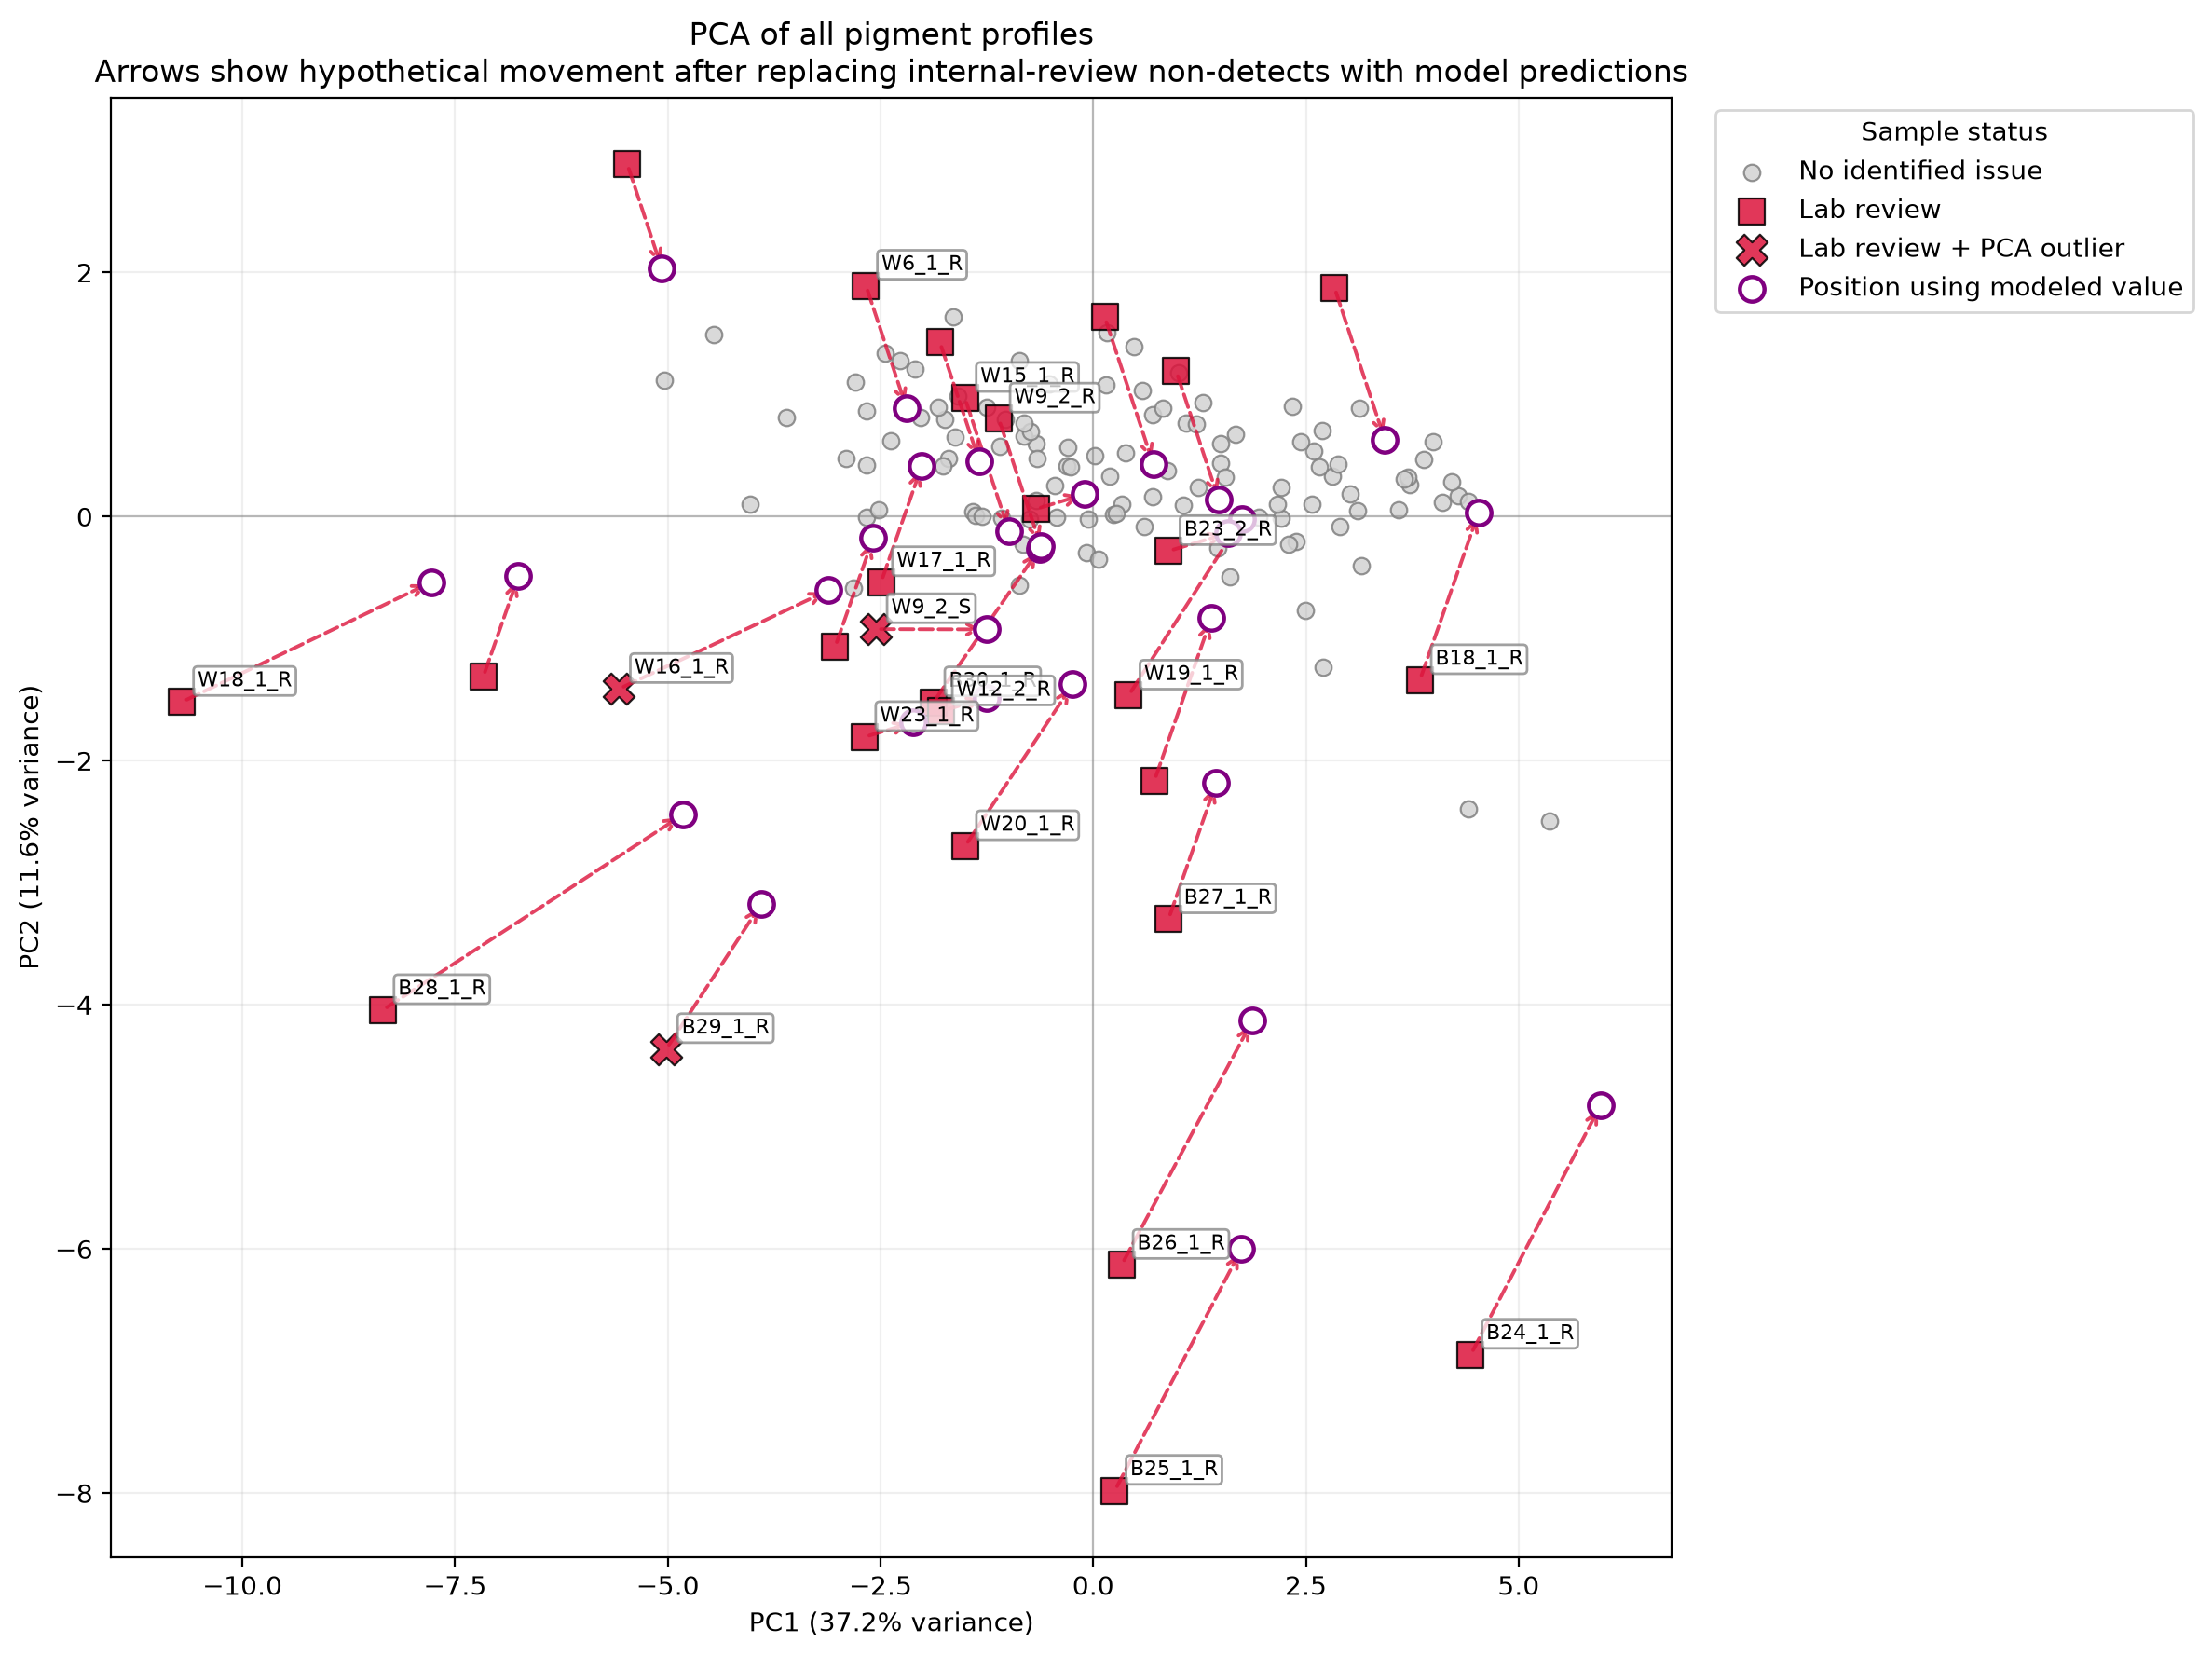

In [68]:
# ============================================================
# PCA OUTLIER ANALYSIS WITH MODELED NON-DETECT POSITIONS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


def run_pigment_pca_analysis(
    qc_results,
    *,
    detection_limit=10.0,
    non_detect_replacement=None,
    variance_to_retain=0.90,
    outlier_quantile=0.99,
    modeled_replacement_scope="internal",
):
    """Run PCA outlier analysis and calculate modeled sample positions.

    The PCA is fitted once using the reported pigment data, with
    non-detects represented by half the detection limit. Selected
    non-detects are then replaced with their model-predicted values,
    and the modified samples are transformed through the same fitted
    imputer, scaler, and PCA.

    Parameters
    ----------
    qc_results : dict
        Output from analyze_pigment_non_detects().
    detection_limit : float
        Detection or reporting limit.
    non_detect_replacement : float, optional
        Value used to represent non-detects during PCA. Defaults to
        half the detection limit.
    variance_to_retain : float
        Proportion of variance used to select the retained PCA
        dimensions for outlier calculations.
    outlier_quantile : float
        Empirical quantile used for the PCA score-distance and
        residual-distance thresholds.
    modeled_replacement_scope : {"lab", "internal", "all_modeled"}
        Determines which non-detects are replaced by model predictions:

        - "lab": only strict unexpected non-detects;
        - "internal": broader internal-review candidates;
        - "all_modeled": every non-detect with an available prediction.

    Returns
    -------
    dict
        PCA coordinates, modeled coordinates, outlier metrics,
        loadings, explained variance, movement information, fitted
        transformations, and the modeled pigment dataset.
    """
    valid_scopes = {
        "lab",
        "internal",
        "all_modeled",
    }

    if modeled_replacement_scope not in valid_scopes:
        raise ValueError(
            f"modeled_replacement_scope must be one of {sorted(valid_scopes)}."
        )

    if not 0 < variance_to_retain <= 1:
        raise ValueError(
            "variance_to_retain must be greater than zero and no greater than one."
        )

    if not 0 < outlier_quantile < 1:
        raise ValueError("outlier_quantile must be between zero and one.")

    if non_detect_replacement is None:
        non_detect_replacement = detection_limit / 2

    data = qc_results["data"].copy()

    if not data.index.is_unique:
        raise ValueError("The pigment dataframe index must uniquely identify samples.")

    if len(data) < 3:
        raise ValueError("At least three samples are required for this PCA analysis.")

    # --------------------------------------------------------
    # Prepare the reported dataset for PCA
    # --------------------------------------------------------

    # Negative concentrations are invalid and are treated as missing.
    reported_for_pca = data.mask(data.lt(0))

    # Non-detects and any other values below the reporting limit are
    # represented by LOD / 2 for the PCA transformation only.
    reported_censored = reported_for_pca.notna() & reported_for_pca.lt(detection_limit)

    reported_for_pca = reported_for_pca.mask(
        reported_censored,
        non_detect_replacement,
    )

    # All remaining finite concentrations must be positive before log10.
    if reported_for_pca.le(0).any().any():
        raise ValueError("Non-positive values remain after non-detect replacement.")

    reported_log = np.log10(reported_for_pca)

    # --------------------------------------------------------
    # Fit imputation and scaling
    # --------------------------------------------------------

    imputer = SimpleImputer(strategy="median")

    reported_imputed = imputer.fit_transform(reported_log)

    scaler = StandardScaler()

    reported_scaled = scaler.fit_transform(reported_imputed)

    maximum_components = min(
        reported_scaled.shape[0] - 1,
        reported_scaled.shape[1],
    )

    if maximum_components < 2:
        raise ValueError("At least two PCA components are required.")

    # Fit the full usable PCA first so the number of retained
    # components can be selected from cumulative explained variance.
    pca = PCA(
        n_components=maximum_components,
        random_state=42,
    )

    reported_scores = pca.fit_transform(reported_scaled)

    component_names = [
        f"PC{number}"
        for number in range(
            1,
            maximum_components + 1,
        )
    ]

    explained_variance = pd.Series(
        100 * pca.explained_variance_ratio_,
        index=component_names,
        name="explained_variance_percent",
    )

    cumulative_variance = explained_variance.cumsum()

    retained_component_count = int(
        np.searchsorted(
            pca.explained_variance_ratio_.cumsum(),
            variance_to_retain,
        )
        + 1
    )

    retained_component_count = max(
        2,
        min(
            retained_component_count,
            maximum_components,
        ),
    )

    retained_components = component_names[:retained_component_count]

    # --------------------------------------------------------
    # Calculate PCA outlier metrics
    # --------------------------------------------------------

    def calculate_pca_metrics(
        scaled_values,
        scores,
    ):
        retained_scores = scores[
            :,
            :retained_component_count,
        ]

        retained_variances = pca.explained_variance_[:retained_component_count]

        safe_variances = np.where(
            retained_variances > 0,
            retained_variances,
            np.nan,
        )

        # Hotelling-style score distance.
        score_distance = np.nansum(
            retained_scores**2 / safe_variances,
            axis=1,
        )

        # Reconstruct standardized observations using the retained PCs.
        reconstructed_scaled = (
            retained_scores @ pca.components_[:retained_component_count, :] + pca.mean_
        )

        residuals = scaled_values - reconstructed_scaled

        residual_distance = np.sum(
            residuals**2,
            axis=1,
        )

        return score_distance, residual_distance

    (
        score_distance,
        residual_distance,
    ) = calculate_pca_metrics(
        reported_scaled,
        reported_scores,
    )

    score_threshold = np.quantile(
        score_distance,
        outlier_quantile,
    )

    residual_threshold = np.quantile(
        residual_distance,
        outlier_quantile,
    )

    score_outlier = score_distance >= score_threshold

    residual_outlier = residual_distance >= residual_threshold

    pca_outlier = score_outlier | residual_outlier

    score_percentile = (
        pd.Series(
            score_distance,
            index=data.index,
        )
        .rank(pct=True)
        .mul(100)
    )

    residual_percentile = (
        pd.Series(
            residual_distance,
            index=data.index,
        )
        .rank(pct=True)
        .mul(100)
    )

    # --------------------------------------------------------
    # Create reported PCA coordinates
    # --------------------------------------------------------

    coordinates = pd.DataFrame(
        reported_scores,
        index=data.index,
        columns=component_names,
    )

    coordinates["score_distance"] = score_distance
    coordinates["score_percentile"] = score_percentile
    coordinates["score_outlier"] = score_outlier

    coordinates["residual_distance"] = residual_distance
    coordinates["residual_percentile"] = residual_percentile
    coordinates["residual_outlier"] = residual_outlier

    coordinates["pca_outlier"] = pca_outlier

    coordinates["maximum_pca_percentile"] = coordinates[
        [
            "score_percentile",
            "residual_percentile",
        ]
    ].max(axis=1)

    # --------------------------------------------------------
    # Add flags from the preceding non-detect analysis
    # --------------------------------------------------------

    internal_report = qc_results.get(
        "internal_review",
        pd.DataFrame(),
    )

    lab_report = qc_results.get(
        "lab_review_non_detects",
        pd.DataFrame(),
    )

    if internal_report.empty:
        internal_index = []
    else:
        internal_index = internal_report.index.unique()

    if lab_report.empty:
        lab_index = []
    else:
        lab_index = lab_report.index.unique()

    coordinates["previous_internal_review"] = coordinates.index.isin(internal_index)

    coordinates["previous_lab_review"] = coordinates.index.isin(lab_index)

    coordinates["plot_category"] = np.select(
        [
            (coordinates["previous_lab_review"] & coordinates["pca_outlier"]),
            coordinates["previous_lab_review"],
            (coordinates["previous_internal_review"] & coordinates["pca_outlier"]),
            coordinates["previous_internal_review"],
            coordinates["pca_outlier"],
        ],
        [
            "Lab review + PCA outlier",
            "Lab review",
            "Internal review + PCA outlier",
            "Internal review",
            "PCA outlier only",
        ],
        default="No identified issue",
    )

    # --------------------------------------------------------
    # Pigment loadings
    # --------------------------------------------------------

    loadings = pd.DataFrame(
        pca.components_.T,
        index=data.columns,
        columns=component_names,
    )

    # --------------------------------------------------------
    # Select non-detects for hypothetical model replacement
    # --------------------------------------------------------

    non_detect_assessment = qc_results["non_detect_assessment"].copy()

    if non_detect_assessment.empty:
        replacements = pd.DataFrame()
    else:
        available_prediction = (
            non_detect_assessment["predicted_value"].notna()
            & np.isfinite(non_detect_assessment["predicted_value"])
            & non_detect_assessment["predicted_value"].gt(0)
        )

        if modeled_replacement_scope == "lab":
            replacement_mask = (
                available_prediction & non_detect_assessment["lab_review_recommended"]
            )

        elif modeled_replacement_scope == "internal":
            replacement_mask = (
                available_prediction
                & non_detect_assessment["internal_review_recommended"]
            )

        else:
            replacement_mask = available_prediction

        replacements = non_detect_assessment.loc[replacement_mask].copy()

    # --------------------------------------------------------
    # Create the hypothetical modeled pigment dataset
    # --------------------------------------------------------

    modeled_data = data.copy()

    if not replacements.empty:
        for sample_index, row in replacements.iterrows():
            modeled_data.at[
                sample_index,
                row["pigment"],
            ] = row["predicted_value"]

    # Use exactly the same preparation assumptions as the reported PCA.
    modeled_for_pca = modeled_data.mask(modeled_data.lt(0))

    modeled_censored = modeled_for_pca.notna() & modeled_for_pca.lt(detection_limit)

    modeled_for_pca = modeled_for_pca.mask(
        modeled_censored,
        non_detect_replacement,
    )

    modeled_log = np.log10(modeled_for_pca)

    # Transform with the original fitted imputer, scaler, and PCA.
    modeled_imputed = imputer.transform(modeled_log)

    modeled_scaled = scaler.transform(modeled_imputed)

    modeled_scores = pca.transform(modeled_scaled)

    modeled_coordinates = pd.DataFrame(
        modeled_scores,
        index=data.index,
        columns=component_names,
    )

    (
        modeled_score_distance,
        modeled_residual_distance,
    ) = calculate_pca_metrics(
        modeled_scaled,
        modeled_scores,
    )

    modeled_coordinates["score_distance"] = modeled_score_distance

    modeled_coordinates["residual_distance"] = modeled_residual_distance

    modeled_coordinates["score_outlier"] = modeled_score_distance >= score_threshold

    modeled_coordinates["residual_outlier"] = (
        modeled_residual_distance >= residual_threshold
    )

    modeled_coordinates["pca_outlier"] = (
        modeled_coordinates["score_outlier"] | modeled_coordinates["residual_outlier"]
    )

    # --------------------------------------------------------
    # Summarize movement after model replacement
    # --------------------------------------------------------

    if replacements.empty:
        movement = pd.DataFrame()
    else:
        affected_index = replacements.index.unique()

        movement = coordinates.loc[
            coordinates.index.isin(affected_index),
            component_names,
        ].copy()

        for component in component_names:
            movement[f"reported_{component}"] = movement[component]

            movement[f"modeled_{component}"] = modeled_coordinates.loc[
                movement.index,
                component,
            ]

            movement[f"change_{component}"] = (
                movement[f"modeled_{component}"] - movement[f"reported_{component}"]
            )

        movement = movement.drop(columns=component_names)

        index_levels = list(range(replacements.index.nlevels))

        modeled_pigments = replacements.groupby(level=index_levels)["pigment"].agg(
            lambda values: ", ".join(pd.unique(values))
        )

        replacement_count = replacements.groupby(level=index_levels).size()

        movement["modeled_pigments"] = modeled_pigments.reindex(movement.index)

        movement["n_modeled_non_detects"] = replacement_count.reindex(movement.index)

        movement["reported_pca_outlier"] = coordinates.loc[
            movement.index,
            "pca_outlier",
        ]

        movement["modeled_pca_outlier"] = modeled_coordinates.loc[
            movement.index,
            "pca_outlier",
        ]

        movement["previous_internal_review"] = coordinates.loc[
            movement.index,
            "previous_internal_review",
        ]

        movement["previous_lab_review"] = coordinates.loc[
            movement.index,
            "previous_lab_review",
        ]

        reported_component_columns = [
            f"reported_{component}" for component in retained_components
        ]

        modeled_component_columns = [
            f"modeled_{component}" for component in retained_components
        ]

        reported_retained = movement[reported_component_columns].to_numpy()

        modeled_retained = movement[modeled_component_columns].to_numpy()

        movement["total_pca_movement"] = np.sqrt(
            np.sum(
                (modeled_retained - reported_retained) ** 2,
                axis=1,
            )
        )

        movement = movement.sort_values(
            "total_pca_movement",
            ascending=False,
        )

    pca_outliers = coordinates.loc[coordinates["pca_outlier"]].copy()

    pca_outliers = pca_outliers.sort_values(
        [
            "maximum_pca_percentile",
            "score_distance",
            "residual_distance",
        ],
        ascending=False,
    )

    return {
        "coordinates": coordinates,
        "modeled_coordinates": modeled_coordinates,
        "movement": movement,
        "replacements": replacements,
        "pca_outliers": pca_outliers,
        "loadings": loadings,
        "explained_variance": explained_variance,
        "cumulative_variance": cumulative_variance,
        "retained_components": retained_components,
        "retained_component_count": retained_component_count,
        "score_threshold": score_threshold,
        "residual_threshold": residual_threshold,
        "reported_pca_data": reported_for_pca,
        "modeled_pigment_data": modeled_data,
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca,
        "settings": {
            "detection_limit": detection_limit,
            "non_detect_replacement": (non_detect_replacement),
            "variance_to_retain": variance_to_retain,
            "outlier_quantile": outlier_quantile,
            "modeled_replacement_scope": (modeled_replacement_scope),
        },
    }


def format_pca_sample_label(index_value):
    """Create a readable label from an Index or MultiIndex value."""
    if isinstance(index_value, tuple):
        return "_".join(map(str, index_value))

    return str(index_value)


def plot_pigment_pca_with_modeled_positions(
    pca_results,
    *,
    x_component="PC1",
    y_component="PC2",
    annotate=True,
    max_labels=20,
    show_modeled_positions=True,
    show_loadings=False,
    max_loading_labels=10,
):
    """Plot reported and hypothetical modeled positions in PCA space."""
    coordinates = pca_results["coordinates"]

    modeled_coordinates = pca_results["modeled_coordinates"]

    movement = pca_results["movement"]
    loadings = pca_results["loadings"]
    variance = pca_results["explained_variance"]

    for component in [
        x_component,
        y_component,
    ]:
        if component not in coordinates.columns:
            raise KeyError(f"{component} is not available in the PCA result.")

    category_styles = {
        "No identified issue": {
            "facecolor": "lightgray",
            "edgecolor": "gray",
            "marker": "o",
            "size": 40,
            "zorder": 1,
        },
        "PCA outlier only": {
            "facecolor": "gold",
            "edgecolor": "black",
            "marker": "o",
            "size": 90,
            "zorder": 3,
        },
        "Internal review": {
            "facecolor": "darkorange",
            "edgecolor": "black",
            "marker": "D",
            "size": 80,
            "zorder": 4,
        },
        "Internal review + PCA outlier": {
            "facecolor": "darkorange",
            "edgecolor": "black",
            "marker": "X",
            "size": 125,
            "zorder": 5,
        },
        "Lab review": {
            "facecolor": "crimson",
            "edgecolor": "black",
            "marker": "s",
            "size": 100,
            "zorder": 6,
        },
        "Lab review + PCA outlier": {
            "facecolor": "crimson",
            "edgecolor": "black",
            "marker": "X",
            "size": 145,
            "zorder": 7,
        },
    }

    fig, ax = plt.subplots(figsize=(12, 9))

    # --------------------------------------------------------
    # Plot reported positions
    # --------------------------------------------------------

    for category, style in category_styles.items():
        subset = coordinates.loc[coordinates["plot_category"].eq(category)]

        if subset.empty:
            continue

        ax.scatter(
            subset[x_component],
            subset[y_component],
            s=style["size"],
            marker=style["marker"],
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.8,
            alpha=0.85,
            label=category,
            zorder=style["zorder"],
        )

    # --------------------------------------------------------
    # Plot movement to modeled positions
    # --------------------------------------------------------

    if show_modeled_positions and not movement.empty:
        for sample_index, row in movement.iterrows():
            reported_x = row[f"reported_{x_component}"]
            reported_y = row[f"reported_{y_component}"]

            modeled_x = row[f"modeled_{x_component}"]
            modeled_y = row[f"modeled_{y_component}"]

            if row["previous_lab_review"]:
                arrow_color = "crimson"
            else:
                arrow_color = "purple"

            ax.annotate(
                "",
                xy=(modeled_x, modeled_y),
                xytext=(reported_x, reported_y),
                arrowprops={
                    "arrowstyle": "->",
                    "color": arrow_color,
                    "linewidth": 1.4,
                    "linestyle": "--",
                    "alpha": 0.8,
                },
                zorder=8,
            )

        modeled_subset = modeled_coordinates.loc[movement.index]

        ax.scatter(
            modeled_subset[x_component],
            modeled_subset[y_component],
            s=90,
            marker="o",
            facecolor="white",
            edgecolor="purple",
            linewidth=1.6,
            label="Position using modeled value",
            zorder=9,
        )

    # --------------------------------------------------------
    # Optionally show the strongest loadings
    # --------------------------------------------------------

    if show_loadings:
        selected_loadings = loadings[
            [
                x_component,
                y_component,
            ]
        ].copy()

        selected_loadings["plane_magnitude"] = np.sqrt(
            selected_loadings[x_component] ** 2 + selected_loadings[y_component] ** 2
        )

        selected_loadings = selected_loadings.sort_values(
            "plane_magnitude",
            ascending=False,
        ).head(max_loading_labels)

        x_span = coordinates[x_component].max() - coordinates[x_component].min()

        y_span = coordinates[y_component].max() - coordinates[y_component].min()

        loading_scale = 0.30 * max(
            min(x_span, y_span),
            1e-12,
        )

        for pigment, loading in selected_loadings.iterrows():
            dx = loading[x_component] * loading_scale

            dy = loading[y_component] * loading_scale

            ax.annotate(
                "",
                xy=(dx, dy),
                xytext=(0, 0),
                arrowprops={
                    "arrowstyle": "->",
                    "color": "navy",
                    "linewidth": 1.3,
                    "alpha": 0.7,
                },
                zorder=10,
            )

            ax.text(
                dx * 1.10,
                dy * 1.10,
                pigment.replace(" (ppb)", ""),
                color="navy",
                fontsize=8,
                fontweight="bold",
                ha="center",
                va="center",
                zorder=11,
            )

    # --------------------------------------------------------
    # Annotate priority samples
    # --------------------------------------------------------

    if annotate:
        label_candidates = coordinates.loc[
            (
                coordinates["pca_outlier"]
                | coordinates["previous_internal_review"]
                | coordinates["previous_lab_review"]
            )
        ].copy()

        label_candidates = label_candidates.sort_values(
            [
                "previous_lab_review",
                "pca_outlier",
                "maximum_pca_percentile",
            ],
            ascending=[
                False,
                False,
                False,
            ],
        ).head(max_labels)

        for sample_index, row in label_candidates.iterrows():
            ax.annotate(
                format_pca_sample_label(sample_index),
                (
                    row[x_component],
                    row[y_component],
                ),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=8,
                color="black",
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "facecolor": "white",
                    "edgecolor": "gray",
                    "alpha": 0.75,
                },
                zorder=12,
            )

    ax.axhline(
        0,
        color="gray",
        linewidth=0.8,
        alpha=0.5,
    )

    ax.axvline(
        0,
        color="gray",
        linewidth=0.8,
        alpha=0.5,
    )

    ax.set_xlabel(f"{x_component} ({variance[x_component]:.1f}% variance)")

    ax.set_ylabel(f"{y_component} ({variance[y_component]:.1f}% variance)")

    replacement_scope = pca_results["settings"]["modeled_replacement_scope"]

    ax.set_title(
        "PCA of all pigment profiles\n"
        "Arrows show hypothetical movement after replacing "
        f"{replacement_scope}-review non-detects with model predictions"
    )

    ax.grid(alpha=0.2)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Sample status",
    )

    fig.tight_layout()

    return fig, ax


# ============================================================
# RUN PCA USING ALL 19 PIGMENTS
# ============================================================

pigment_pca_qc = run_pigment_pca_analysis(
    pigment_non_detect_qc,
    detection_limit=10.0,
    non_detect_replacement=5.0,
    variance_to_retain=0.90,
    outlier_quantile=0.99,
    # Options:
    # "lab"         = only strict unexpected non-detects
    # "internal"    = broader internal-review candidates
    # "all_modeled" = every non-detect with a prediction
    modeled_replacement_scope="internal",
)


# ============================================================
# DISPLAY NUMERICAL RESULTS
# ============================================================

print(
    "Number of retained PCA components:",
    pigment_pca_qc["retained_component_count"],
)

print(
    "Retained components:",
    ", ".join(pigment_pca_qc["retained_components"]),
)

print(
    "Cumulative variance retained:",
    f"{pigment_pca_qc['explained_variance'].iloc[: pigment_pca_qc['retained_component_count']].sum():.1f}%",
)

print(
    "PCA score-distance threshold:",
    f"{pigment_pca_qc['score_threshold']:.3f}",
)

print(
    "PCA residual-distance threshold:",
    f"{pigment_pca_qc['residual_threshold']:.3f}",
)


print("\nEXPLAINED VARIANCE")

display(
    pd.concat(
        [
            pigment_pca_qc["explained_variance"],
            pigment_pca_qc["cumulative_variance"].rename("cumulative_variance_percent"),
        ],
        axis=1,
    ).head(10)
)


print("\nPCA OUTLIERS")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(
        pigment_pca_qc["pca_outliers"][
            [
                "PC1",
                "PC2",
                "score_distance",
                "score_percentile",
                "score_outlier",
                "residual_distance",
                "residual_percentile",
                "residual_outlier",
                "previous_internal_review",
                "previous_lab_review",
                "plot_category",
            ]
        ]
    )


print("\nMOVEMENT AFTER REPLACING NON-DETECTS WITH MODELED VALUES")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(pigment_pca_qc["movement"])


# ============================================================
# PC1 VERSUS PC2
# ============================================================

fig, ax = plot_pigment_pca_with_modeled_positions(
    pigment_pca_qc,
    x_component="PC1",
    y_component="PC2",
    annotate=True,
    max_labels=20,
    show_modeled_positions=True,
    show_loadings=False,
)


# Other possible component combinations:
#
# fig, ax = plot_pigment_pca_with_modeled_positions(
#     pigment_pca_qc,
#     x_component="PC1",
#     y_component="PC3",
#     annotate=True,
#     max_labels=20,
#     show_modeled_positions=True,
#     show_loadings=False,
# )
#
# fig, ax = plot_pigment_pca_with_modeled_positions(
#     pigment_pca_qc,
#     x_component="PC2",
#     y_component="PC3",
#     annotate=True,
#     max_labels=20,
#     show_modeled_positions=True,
#     show_loadings=False,
# )
#
# To show the ten pigments with the strongest loadings in the
# selected PCA plane, set:
#
# show_loadings=True


In [69]:
def plot_pigment_pca_with_modeled_positions(
    pca_results,
    *,
    x_component="PC1",
    y_component="PC2",
    modeled_position_filter="lab_review_pca",
    annotate=True,
    max_labels=20,
    show_modeled_positions=True,
    show_loadings=False,
    max_loading_labels=10,
    background_alpha=0.30,
    highlighted_alpha=0.70,
    modeled_alpha=0.90,
    arrow_alpha=0.65,
    marker_size_scale=1.0,
):
    """Plot reported and hypothetical modeled positions in PCA space.

    All reported samples are displayed. The modeled_position_filter
    argument determines which samples receive a hypothetical modeled
    position and an arrow connecting the reported and modeled positions.

    Parameters
    ----------
    pca_results : dict
        Output from run_pigment_pca_analysis().
    x_component, y_component : str
        PCA components to display, such as "PC1" and "PC2".
    modeled_position_filter : str
        Samples for which modeled positions are displayed. Options are:

        - "none":
            Do not display any modeled positions.

        - "all_modeled":
            Display every available modeled position in the movement
            table.

        - "pca_outlier":
            Display modeled positions for all PCA outliers.

        - "internal_review":
            Display broader internal-review samples, excluding samples
            classified as strict lab-review candidates.

        - "internal_review_pca":
            Display internal-review-only samples that are also PCA
            outliers.

        - "lab_review":
            Display all strict lab-review samples, regardless of PCA
            status.

        - "lab_review_pca":
            Display only samples that are both strict lab-review
            candidates and PCA outliers.

        - "any_review":
            Display all internal- or lab-review samples.

        - "any_review_pca":
            Display all internal- or lab-review samples that are also
            PCA outliers.

    annotate : bool
        Whether to annotate priority samples at their reported position.
    max_labels : int
        Maximum number of reported samples to annotate.
    show_modeled_positions : bool
        Master switch controlling whether modeled positions are shown.
    show_loadings : bool
        Whether to display the strongest pigment loading arrows.
    max_loading_labels : int
        Maximum number of loading arrows to display.
    background_alpha : float
        Transparency of samples with no identified issue.
    highlighted_alpha : float
        Transparency of PCA and review candidates.
    modeled_alpha : float
        Transparency of hollow modeled-position markers.
    arrow_alpha : float
        Transparency of arrows between reported and modeled positions.
    marker_size_scale : float
        Multiplier applied to all reported marker sizes.

    Returns
    -------
    tuple
        Matplotlib figure and axes.
    """
    valid_position_filters = {
        "none",
        "all_modeled",
        "pca_outlier",
        "internal_review",
        "internal_review_pca",
        "lab_review",
        "lab_review_pca",
        "any_review",
        "any_review_pca",
    }

    if modeled_position_filter not in valid_position_filters:
        raise ValueError(
            "modeled_position_filter must be one of:\n- "
            + "\n- ".join(sorted(valid_position_filters))
        )

    for alpha_name, alpha_value in {
        "background_alpha": background_alpha,
        "highlighted_alpha": highlighted_alpha,
        "modeled_alpha": modeled_alpha,
        "arrow_alpha": arrow_alpha,
    }.items():
        if not 0 <= alpha_value <= 1:
            raise ValueError(f"{alpha_name} must be between 0 and 1.")

    coordinates = pca_results["coordinates"].copy()

    modeled_coordinates = pca_results["modeled_coordinates"].copy()

    movement = pca_results["movement"].copy()

    loadings = pca_results["loadings"]

    variance = pca_results["explained_variance"]

    for component in [
        x_component,
        y_component,
    ]:
        if component not in coordinates.columns:
            raise KeyError(f"{component} is not available in the PCA results.")

        if component not in modeled_coordinates.columns:
            raise KeyError(
                f"{component} is not available in the modeled PCA coordinates."
            )

    # --------------------------------------------------------
    # Select samples that will receive modeled positions
    # --------------------------------------------------------

    if (
        not show_modeled_positions
        or movement.empty
        or modeled_position_filter == "none"
    ):
        displayed_movement = movement.iloc[0:0].copy()

    elif modeled_position_filter == "all_modeled":
        displayed_movement = movement.copy()

    else:
        # Obtain the sample flags in the same order as the
        # movement table.
        movement_status = coordinates.reindex(movement.index)

        is_pca_outlier = movement_status["pca_outlier"].fillna(False).astype(bool)

        is_internal = (
            movement_status["previous_internal_review"].fillna(False).astype(bool)
        )

        is_lab = movement_status["previous_lab_review"].fillna(False).astype(bool)

        # Internal-only excludes the stricter lab-review subset.
        is_internal_only = is_internal & ~is_lab

        is_any_review = is_internal | is_lab

        filter_masks = {
            "pca_outlier": is_pca_outlier,
            "internal_review": is_internal_only,
            "internal_review_pca": (is_internal_only & is_pca_outlier),
            "lab_review": is_lab,
            "lab_review_pca": (is_lab & is_pca_outlier),
            "any_review": is_any_review,
            "any_review_pca": (is_any_review & is_pca_outlier),
        }

        selected_mask = filter_masks[modeled_position_filter]

        displayed_movement = movement.loc[selected_mask.to_numpy()].copy()

    # --------------------------------------------------------
    # Plotting styles
    # --------------------------------------------------------

    category_styles = {
        "No identified issue": {
            "facecolor": "lightgray",
            "edgecolor": "gray",
            "marker": "o",
            "size": 40,
            "alpha": background_alpha,
            "zorder": 1,
        },
        "PCA outlier only": {
            "facecolor": "gold",
            "edgecolor": "black",
            "marker": "o",
            "size": 90,
            "alpha": highlighted_alpha,
            "zorder": 3,
        },
        "Internal review": {
            "facecolor": "darkorange",
            "edgecolor": "black",
            "marker": "D",
            "size": 80,
            "alpha": highlighted_alpha,
            "zorder": 4,
        },
        "Internal review + PCA outlier": {
            "facecolor": "darkorange",
            "edgecolor": "black",
            "marker": "X",
            "size": 125,
            "alpha": highlighted_alpha,
            "zorder": 5,
        },
        "Lab review": {
            "facecolor": "crimson",
            "edgecolor": "black",
            "marker": "s",
            "size": 100,
            "alpha": highlighted_alpha,
            "zorder": 6,
        },
        "Lab review + PCA outlier": {
            "facecolor": "crimson",
            "edgecolor": "black",
            "marker": "X",
            "size": 145,
            "alpha": highlighted_alpha,
            "zorder": 7,
        },
    }

    def format_sample_label(index_value):
        """Create a readable label from an Index or MultiIndex."""
        if isinstance(index_value, tuple):
            return "_".join(map(str, index_value))

        return str(index_value)

    def movement_color(sample_index):
        """Select an arrow color based on the sample status."""
        status = coordinates.loc[sample_index]

        if status["previous_lab_review"] and status["pca_outlier"]:
            return "darkred"

        if status["previous_lab_review"]:
            return "crimson"

        if status["previous_internal_review"] and status["pca_outlier"]:
            return "darkorange"

        if status["previous_internal_review"]:
            return "purple"

        if status["pca_outlier"]:
            return "goldenrod"

        return "steelblue"

    fig, ax = plt.subplots(figsize=(12, 9))

    # --------------------------------------------------------
    # Plot all reported sample positions
    # --------------------------------------------------------

    for category, style in category_styles.items():
        subset = coordinates.loc[coordinates["plot_category"].eq(category)]

        if subset.empty:
            continue

        ax.scatter(
            subset[x_component],
            subset[y_component],
            s=(style["size"] * marker_size_scale),
            marker=style["marker"],
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.8,
            alpha=style["alpha"],
            label=category,
            zorder=style["zorder"],
        )

    # --------------------------------------------------------
    # Add arrows and modeled positions for selected samples
    # --------------------------------------------------------

    if not displayed_movement.empty:
        modeled_edge_colors = []

        for sample_index, row in displayed_movement.iterrows():
            reported_x = row[f"reported_{x_component}"]

            reported_y = row[f"reported_{y_component}"]

            modeled_x = row[f"modeled_{x_component}"]

            modeled_y = row[f"modeled_{y_component}"]

            color = movement_color(sample_index)

            modeled_edge_colors.append(color)

            ax.annotate(
                "",
                xy=(
                    modeled_x,
                    modeled_y,
                ),
                xytext=(
                    reported_x,
                    reported_y,
                ),
                arrowprops={
                    "arrowstyle": "-|>",
                    "color": color,
                    "linewidth": 1.5,
                    "linestyle": "--",
                    "alpha": arrow_alpha,
                    "shrinkA": 3,
                    "shrinkB": 3,
                },
                zorder=8,
            )

        modeled_subset = modeled_coordinates.reindex(displayed_movement.index)

        # Hollow markers prevent modeled positions from hiding
        # reported points underneath.
        ax.scatter(
            modeled_subset[x_component],
            modeled_subset[y_component],
            s=100 * marker_size_scale,
            marker="o",
            facecolors="none",
            edgecolors=modeled_edge_colors,
            linewidth=1.8,
            alpha=modeled_alpha,
            label=("Position using modeled non-detect value"),
            zorder=9,
        )

    # --------------------------------------------------------
    # Optionally show strongest pigment loadings
    # --------------------------------------------------------

    if show_loadings:
        selected_loadings = loadings[
            [
                x_component,
                y_component,
            ]
        ].copy()

        selected_loadings["plane_magnitude"] = np.sqrt(
            selected_loadings[x_component] ** 2 + selected_loadings[y_component] ** 2
        )

        selected_loadings = selected_loadings.sort_values(
            "plane_magnitude",
            ascending=False,
        ).head(max_loading_labels)

        x_span = coordinates[x_component].max() - coordinates[x_component].min()

        y_span = coordinates[y_component].max() - coordinates[y_component].min()

        loading_scale = 0.30 * max(
            min(x_span, y_span),
            1e-12,
        )

        for pigment, loading in selected_loadings.iterrows():
            dx = loading[x_component] * loading_scale

            dy = loading[y_component] * loading_scale

            ax.annotate(
                "",
                xy=(dx, dy),
                xytext=(0, 0),
                arrowprops={
                    "arrowstyle": "->",
                    "color": "navy",
                    "linewidth": 1.3,
                    "alpha": 0.60,
                },
                zorder=10,
            )

            ax.text(
                dx * 1.10,
                dy * 1.10,
                pigment.replace(" (ppb)", ""),
                color="navy",
                fontsize=8,
                fontweight="bold",
                alpha=0.80,
                ha="center",
                va="center",
                zorder=11,
            )

    # --------------------------------------------------------
    # Annotate priority samples at their reported positions
    # --------------------------------------------------------

    if annotate:
        label_candidates = coordinates.loc[
            (
                coordinates["pca_outlier"]
                | coordinates["previous_internal_review"]
                | coordinates["previous_lab_review"]
            )
        ].copy()

        # Give precedence to samples for which a modeled position
        # is actually displayed.
        label_candidates["_modeled_position_displayed"] = label_candidates.index.isin(
            displayed_movement.index
        )

        label_candidates = label_candidates.sort_values(
            [
                "_modeled_position_displayed",
                "previous_lab_review",
                "pca_outlier",
                "maximum_pca_percentile",
            ],
            ascending=[
                False,
                False,
                False,
                False,
            ],
        ).head(max_labels)

        for sample_index, row in label_candidates.iterrows():
            ax.annotate(
                format_sample_label(sample_index),
                (
                    row[x_component],
                    row[y_component],
                ),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=8,
                color="black",
                alpha=0.85,
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "facecolor": "white",
                    "edgecolor": "gray",
                    "alpha": 0.55,
                },
                zorder=12,
            )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.axhline(
        0,
        color="gray",
        linewidth=0.8,
        alpha=0.40,
    )

    ax.axvline(
        0,
        color="gray",
        linewidth=0.8,
        alpha=0.40,
    )

    ax.set_xlabel(f"{x_component} ({variance[x_component]:.1f}% variance)")

    ax.set_ylabel(f"{y_component} ({variance[y_component]:.1f}% variance)")

    n_modeled_positions = len(displayed_movement)

    ax.set_title(
        "PCA of all pigment profiles\n"
        f"Modeled-position filter: "
        f"{modeled_position_filter}; "
        f"{n_modeled_positions} sample(s) displayed"
    )

    ax.grid(alpha=0.15)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Reported sample status",
    )

    fig.tight_layout()

    return fig, ax


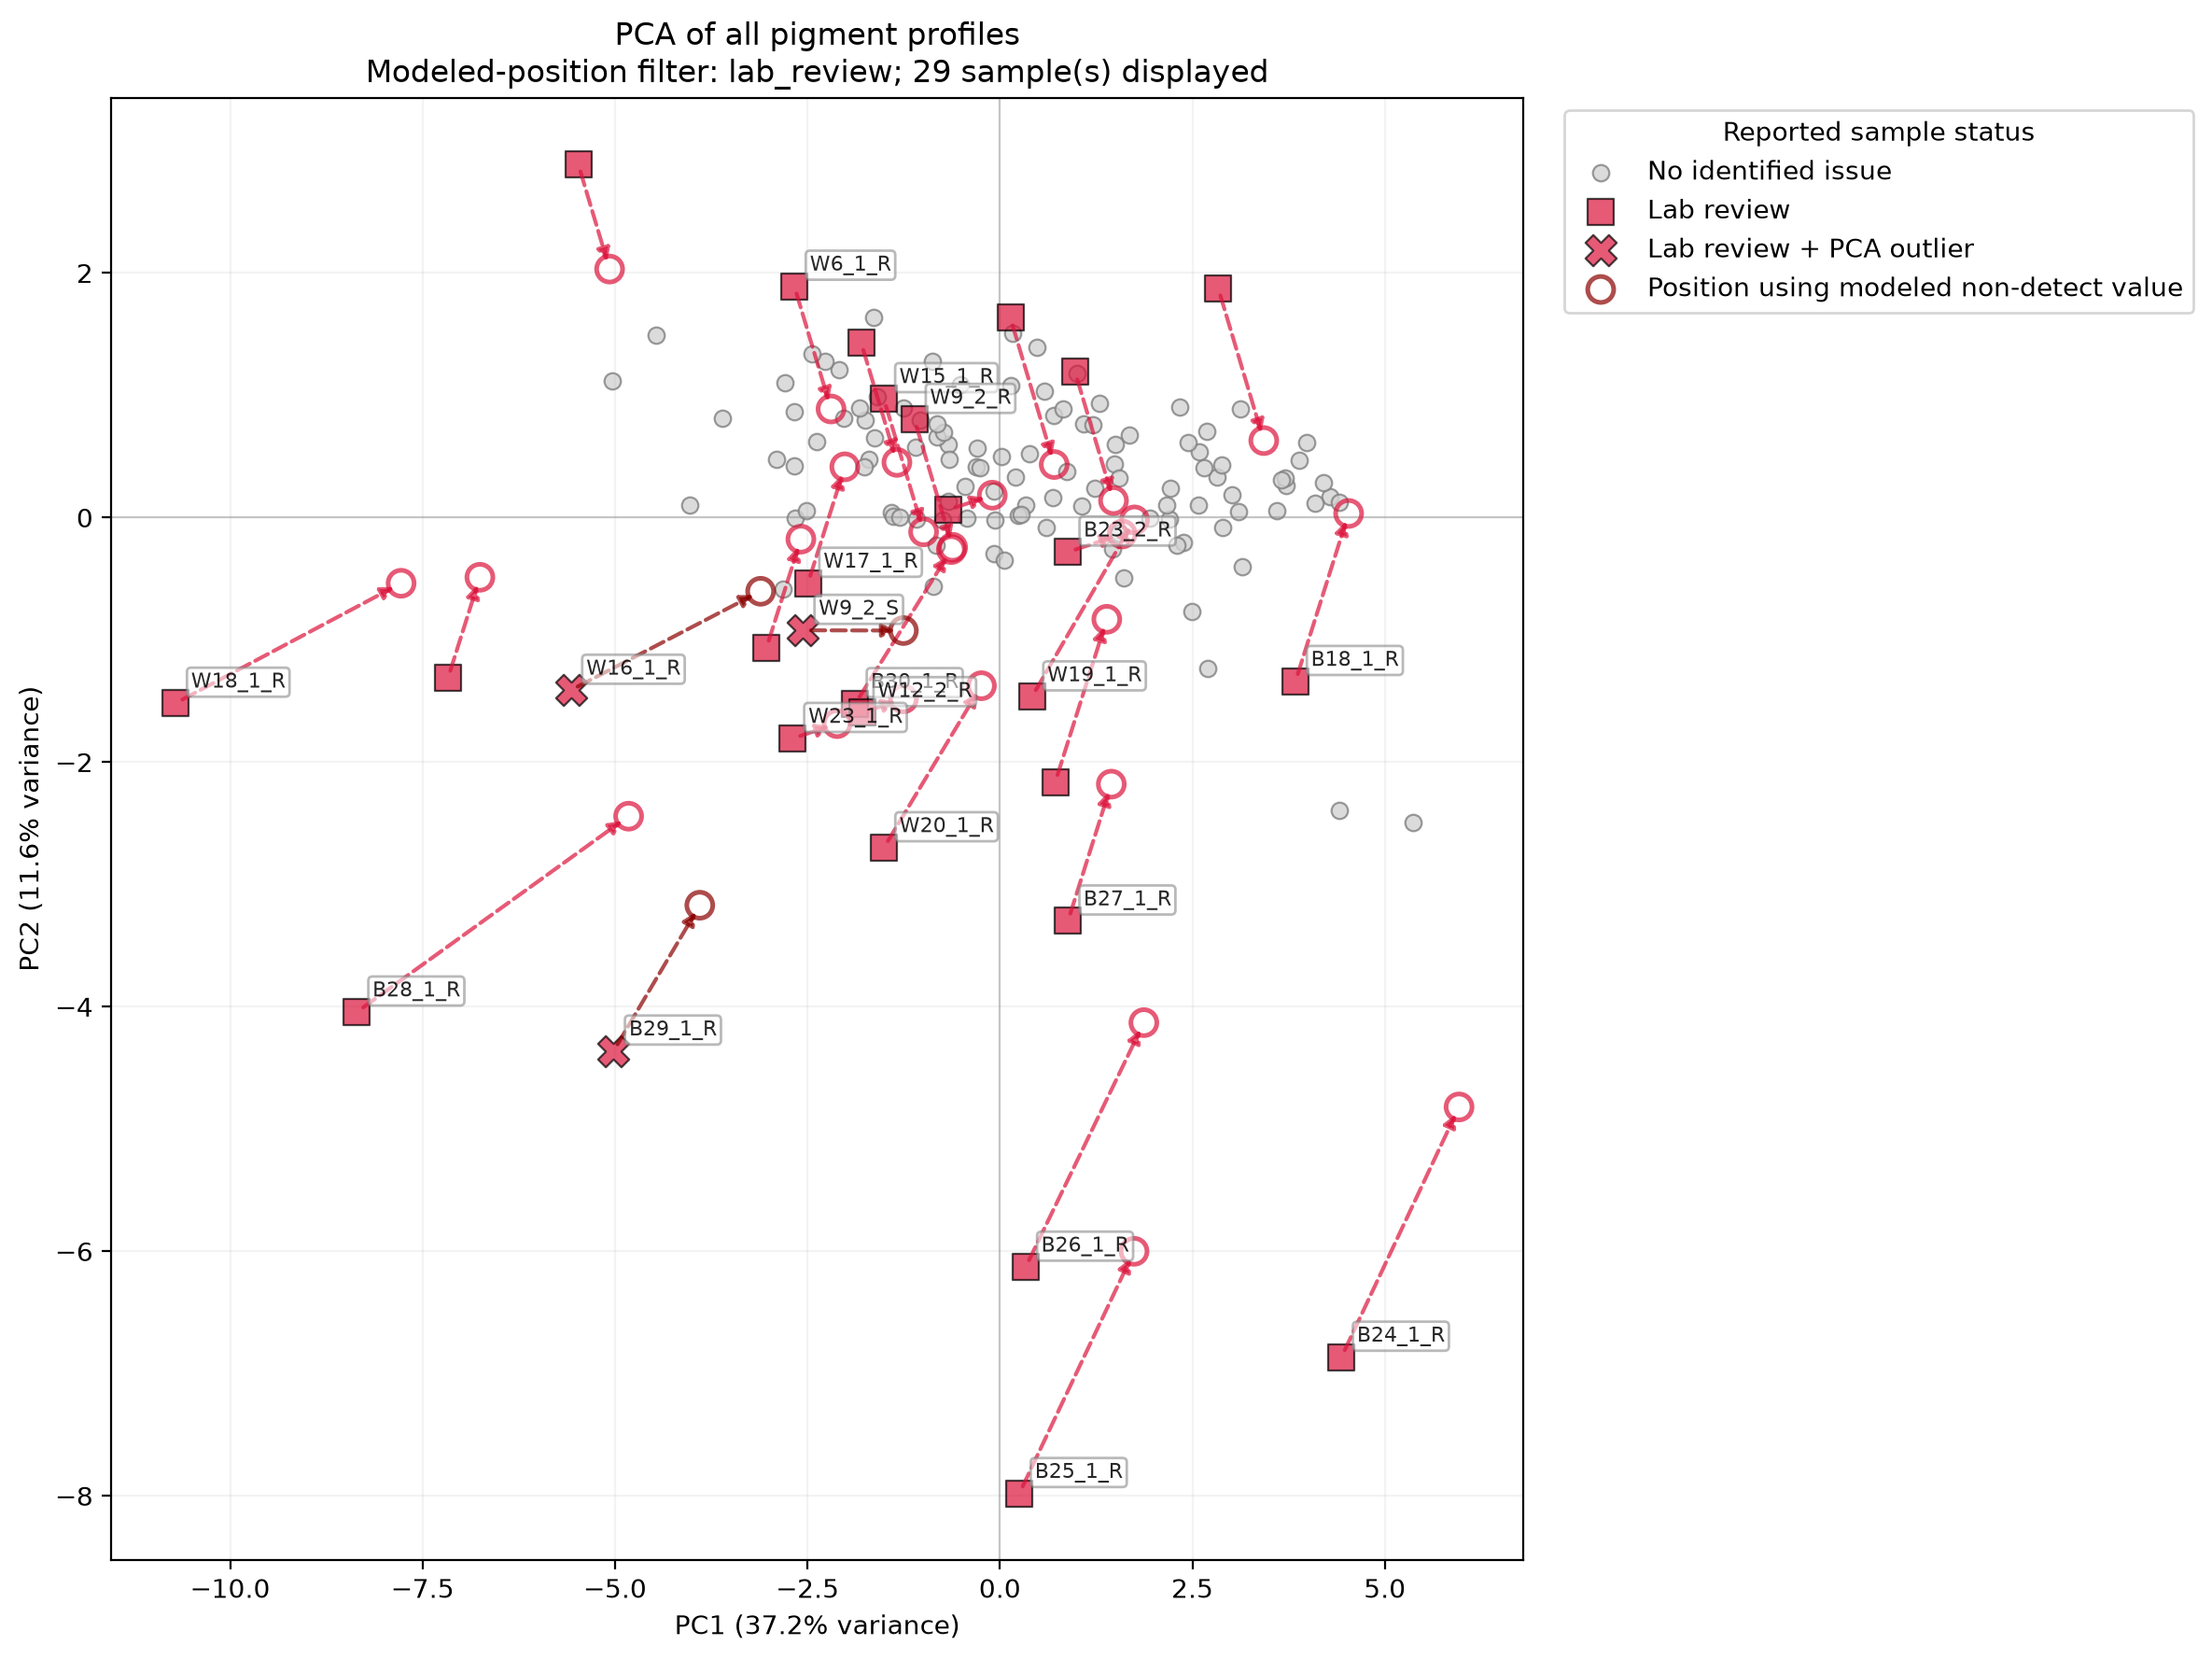

In [70]:
fig, ax = plot_pigment_pca_with_modeled_positions(
    pigment_pca_qc,
    x_component="PC1",
    y_component="PC2",
    modeled_position_filter="lab_review",
    annotate=True,
    max_labels=20,
    show_modeled_positions=True,
    show_loadings=False,
    background_alpha=0.8,
    highlighted_alpha=0.7,
    modeled_alpha=0.7,
    arrow_alpha=0.70,
)


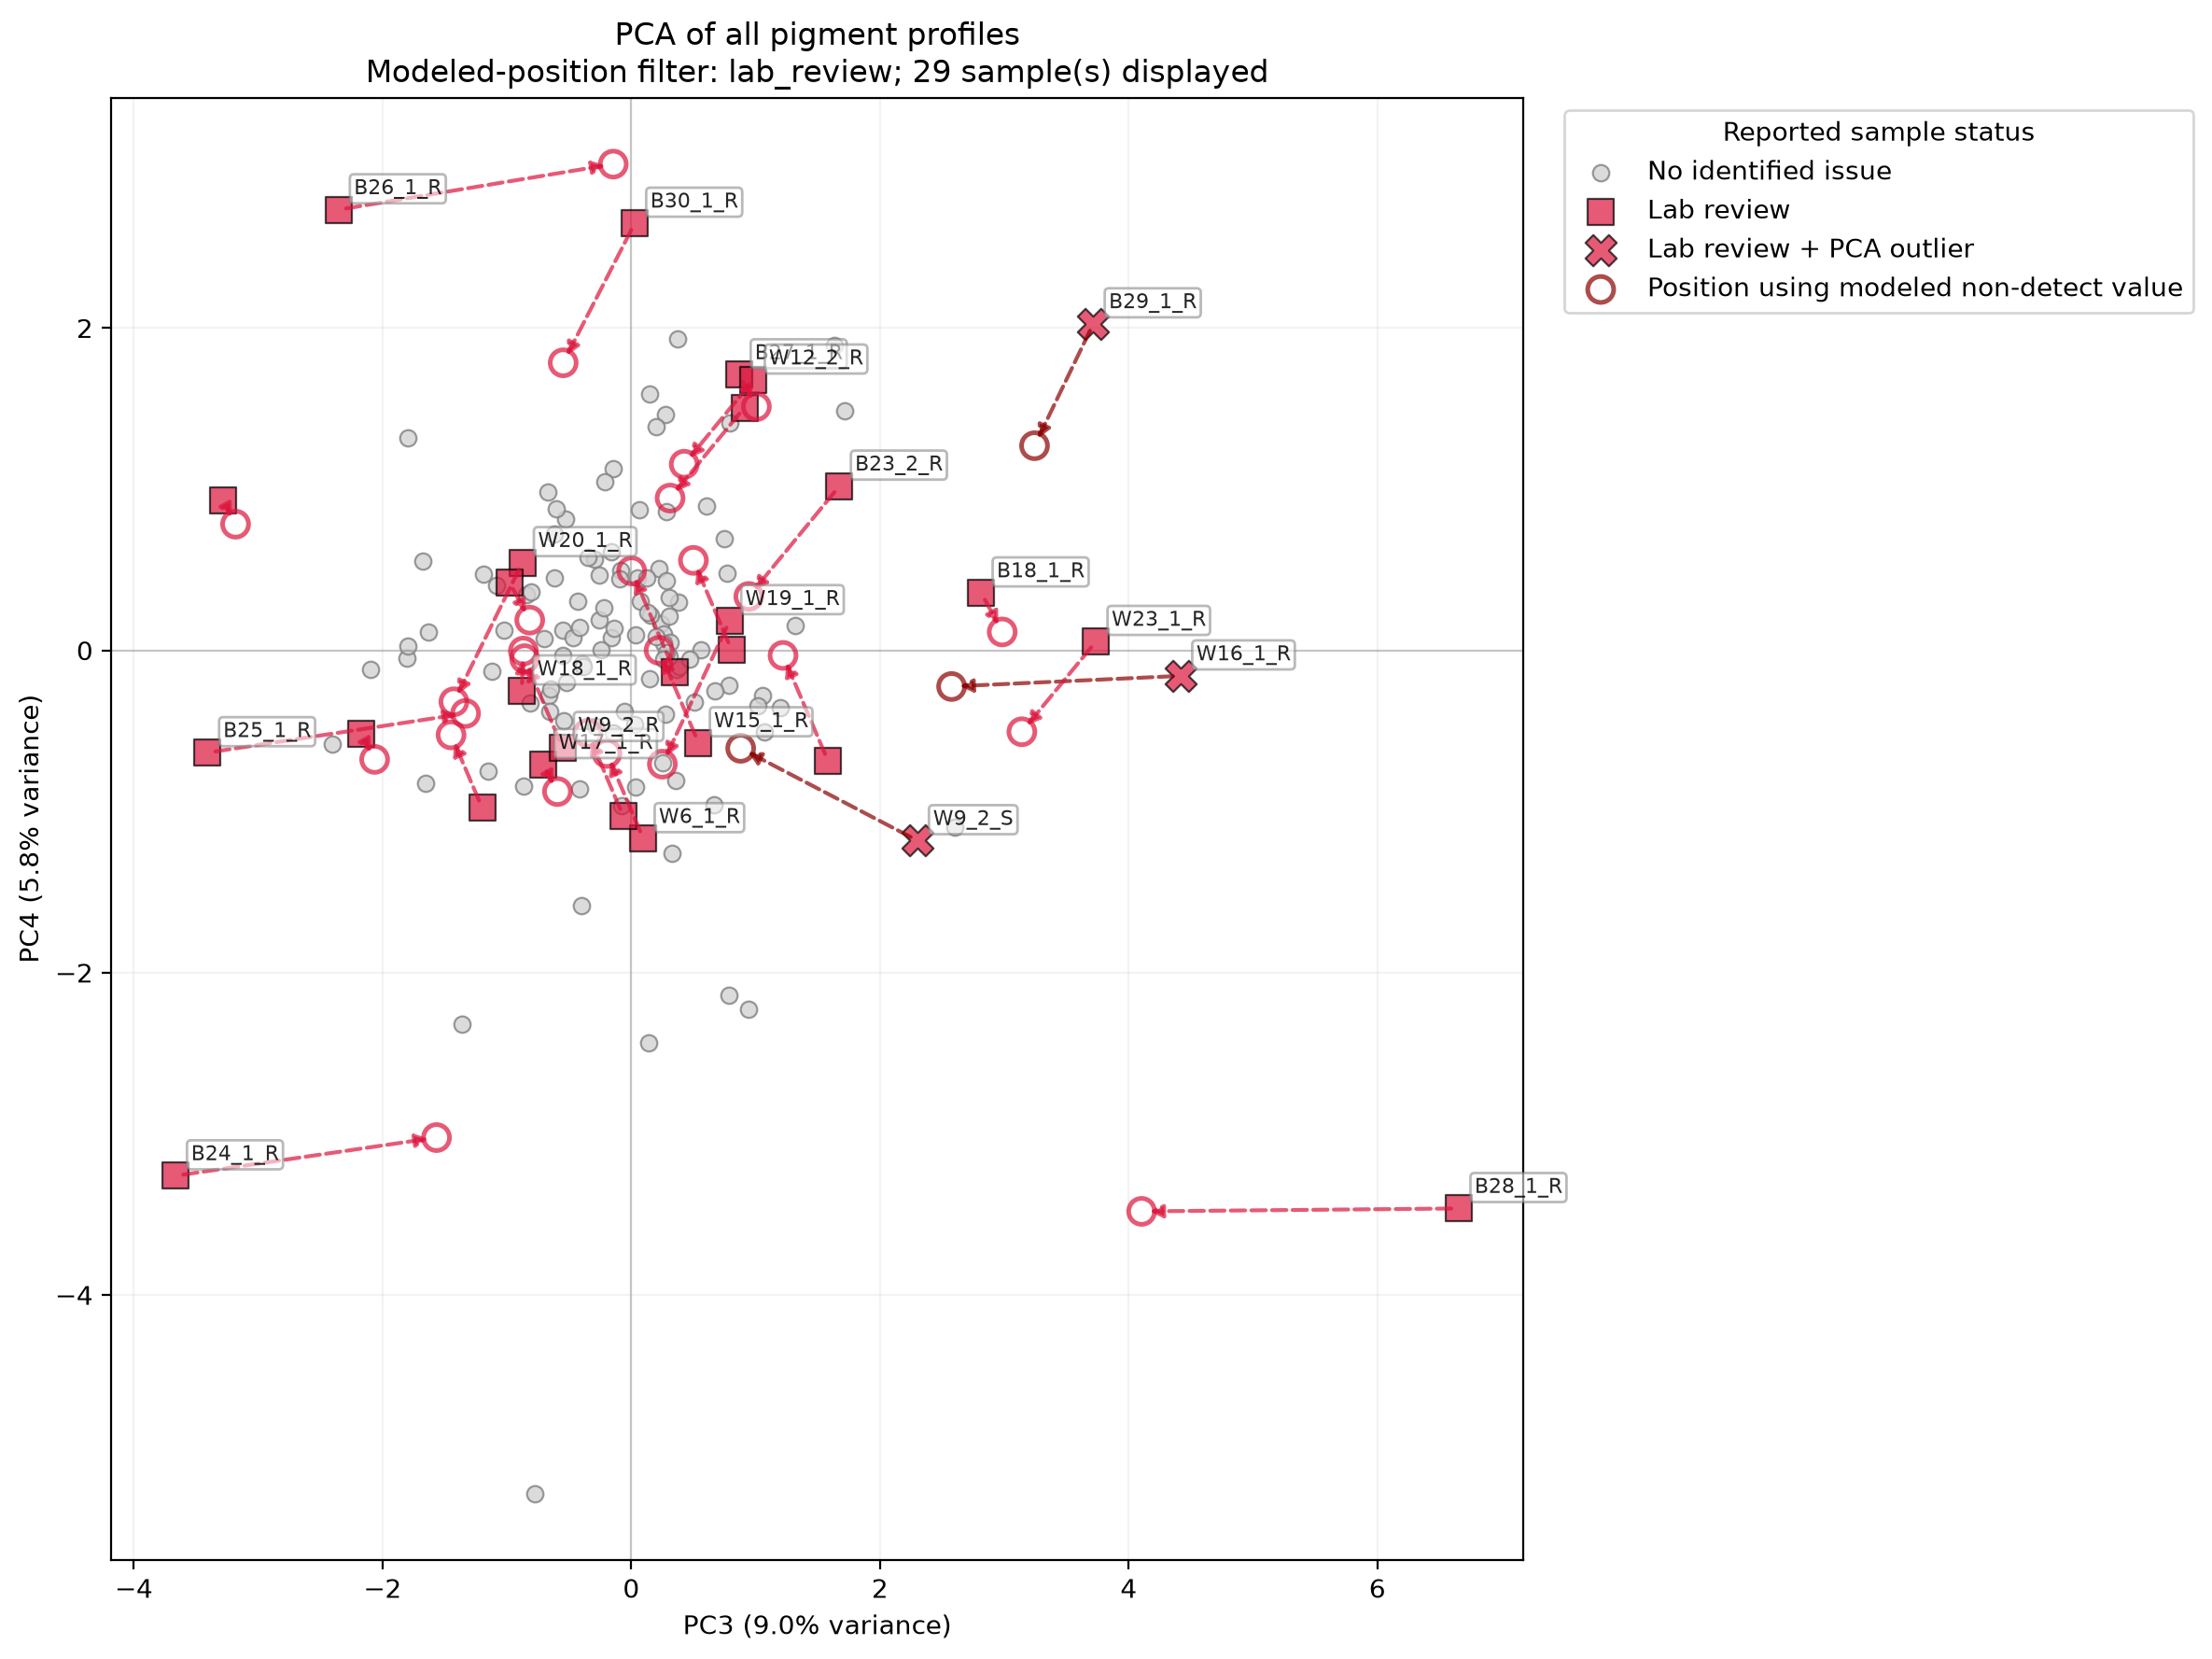

In [71]:
fig, ax = plot_pigment_pca_with_modeled_positions(
    pigment_pca_qc,
    x_component="PC3",
    y_component="PC4",
    modeled_position_filter="lab_review",
    annotate=True,
    max_labels=20,
    show_modeled_positions=True,
    show_loadings=False,
    background_alpha=0.8,
    highlighted_alpha=0.7,
    modeled_alpha=0.7,
    arrow_alpha=0.70,
)


In [72]:
# ============================================================
# REFINE INTERNAL- AND LAB-REVIEW CLASSIFICATIONS
# ============================================================

import numpy as np
import pandas as pd


def refine_non_detect_review_flags(
    qc_results,
    *,
    detection_limit=10.0,
    context_high_quantile=0.90,
    strong_context_min_high=4,
    minimum_internal_model_r2=0.50,
    internal_prediction_multiple=1.50,
):
    """Refine review categories for modeled pigment non-detects.

    This function uses the existing model predictions in the output
    from analyze_pigment_non_detects(). It does not refit the models.

    Internal review requires reliable model evidence. Elevated values
    of other pigments are retained as contextual information but do
    not trigger internal review by themselves.

    Parameters
    ----------
    qc_results : dict
        Output from analyze_pigment_non_detects().
    detection_limit : float
        Laboratory detection or reporting limit.
    context_high_quantile : float
        Quantile used to classify another pigment as relatively high.
        A value of 0.90 means the upper 10% of quantifiable results.
    strong_context_min_high : int
        Minimum number of other high pigments needed for a strong
        context flag.
    minimum_internal_model_r2 : float
        Minimum cross-validated model R-squared required for an
        internal model-based review flag.
    internal_prediction_multiple : float
        Central model prediction must exceed this multiple of the
        detection limit for internal review. At 1.5 and an LOD of
        10 ppb, the predicted concentration must be at least 15 ppb.

    Returns
    -------
    dict
        Updated copy of the QC results dictionary.
    """
    if detection_limit <= 0:
        raise ValueError("detection_limit must be greater than zero.")

    if not 0 < context_high_quantile < 1:
        raise ValueError("context_high_quantile must be between zero and one.")

    if strong_context_min_high < 1:
        raise ValueError("strong_context_min_high must be at least 1.")

    if internal_prediction_multiple < 1:
        raise ValueError("internal_prediction_multiple must be at least 1.")

    refined_results = qc_results.copy()

    data = (
        qc_results["data"]
        .copy()
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

    assessment = qc_results["non_detect_assessment"].copy()

    # --------------------------------------------------------
    # Recalculate the high-pigment context using the selected
    # quantile and only quantifiable observations.
    # --------------------------------------------------------

    quantifiable_mask = data.ge(detection_limit)

    quantifiable_data = data.where(quantifiable_mask)

    high_context_thresholds = quantifiable_data.quantile(context_high_quantile)

    high_value_mask = quantifiable_data.ge(
        high_context_thresholds,
        axis="columns",
    )

    if assessment.empty:
        refined_results["high_context_thresholds"] = high_context_thresholds

        refined_results["internal_review"] = pd.DataFrame()

        refined_results["context_review"] = pd.DataFrame()

        refined_results["lab_review_non_detects"] = pd.DataFrame()

        return refined_results

    # Initialize or overwrite context columns.
    assessment["n_other_quantifiable"] = 0
    assessment["n_other_high"] = 0
    assessment["high_other_pigments"] = ""
    assessment["maximum_other_value"] = np.nan
    assessment["sum_other_quantifiable"] = np.nan

    # Recalculate context separately for every target pigment.
    for target in data.columns:
        target_rows = assessment["pigment"].eq(target)

        if not target_rows.any():
            continue

        sample_index = assessment.index[target_rows]

        other_columns = [column for column in data.columns if column != target]

        other_values = data.loc[
            sample_index,
            other_columns,
        ]

        other_quantifiable = quantifiable_mask.loc[
            sample_index,
            other_columns,
        ]

        other_high = high_value_mask.loc[
            sample_index,
            other_columns,
        ]

        n_other_quantifiable = other_quantifiable.sum(axis=1)

        n_other_high = other_high.sum(axis=1)

        high_other_pigments = other_high.apply(
            lambda row: ", ".join(
                pigment for pigment, is_high in row.items() if is_high
            ),
            axis=1,
        )

        maximum_other_value = other_values.max(axis=1)

        sum_other_quantifiable = other_values.where(other_quantifiable).sum(
            axis=1,
            min_count=1,
        )

        # Assignment uses arrays to preserve the exact row order,
        # including when assessment has repeated sample indices.
        assessment.loc[
            target_rows,
            "n_other_quantifiable",
        ] = n_other_quantifiable.to_numpy()

        assessment.loc[
            target_rows,
            "n_other_high",
        ] = n_other_high.to_numpy()

        assessment.loc[
            target_rows,
            "high_other_pigments",
        ] = high_other_pigments.to_numpy()

        assessment.loc[
            target_rows,
            "maximum_other_value",
        ] = maximum_other_value.to_numpy()

        assessment.loc[
            target_rows,
            "sum_other_quantifiable",
        ] = sum_other_quantifiable.to_numpy()

    # --------------------------------------------------------
    # Reclassify the transparent context information
    # --------------------------------------------------------

    assessment["context_class"] = np.select(
        [
            assessment["n_other_high"].ge(strong_context_min_high),
            assessment["n_other_high"].ge(1),
            assessment["n_other_quantifiable"].gt(0),
        ],
        [
            "non_detect_with_strong_high_pigment_context",
            "non_detect_with_some_high_pigment_context",
            "non_detect_with_other_quantifiable_pigments",
        ],
        default=("non_detect_with_no_other_quantifiable_pigments"),
    )

    assessment["strong_pigment_context"] = assessment["n_other_high"].ge(
        strong_context_min_high
    )

    # --------------------------------------------------------
    # Define internal model reliability separately
    # --------------------------------------------------------

    assessment["internal_model_is_reliable"] = (
        assessment["model_cv_r2_log"].ge(minimum_internal_model_r2).fillna(False)
    )

    internal_prediction_threshold = internal_prediction_multiple * detection_limit

    # Moderate evidence is less strict than the lab-review rule,
    # but still requires a reliable cross-validated model.
    assessment["moderate_model_evidence"] = (
        assessment["internal_model_is_reliable"]
        & assessment["outside_normal_model_error"].fillna(False)
        & assessment["predicted_value"].ge(internal_prediction_threshold)
    )

    # --------------------------------------------------------
    # Strict laboratory-review definition
    # --------------------------------------------------------

    # Keep the existing strict unexpected-non-detect result.
    #
    # It was defined using:
    # - reliable model;
    # - conservative prediction lower bound > detection limit;
    # - central prediction >= 2 times the detection limit.
    assessment["lab_review_recommended"] = assessment["unexpected_non_detect"].fillna(
        False
    )

    # --------------------------------------------------------
    # Revised internal-review definition
    # --------------------------------------------------------

    # Context alone no longer triggers internal review.
    assessment["internal_review_recommended"] = (
        assessment["unexpected_non_detect"].fillna(False)
        | assessment["moderate_model_evidence"]
    )

    # Context-only candidates are retained separately.
    assessment["context_review_recommended"] = (
        assessment["strong_pigment_context"]
        & ~assessment["internal_review_recommended"]
    )

    # --------------------------------------------------------
    # Assign review priority
    # --------------------------------------------------------

    assessment["review_priority"] = np.select(
        [
            assessment["lab_review_recommended"],
            assessment["moderate_model_evidence"],
            assessment["context_review_recommended"],
            assessment["n_other_high"].ge(1),
        ],
        [
            "high",
            "medium",
            "context",
            "informational",
        ],
        default="informational",
    )

    assessment["review_reason"] = np.select(
        [
            assessment["lab_review_recommended"],
            assessment["moderate_model_evidence"],
            assessment["context_review_recommended"],
            assessment["n_other_high"].ge(1),
        ],
        [
            (
                "Reliable model identifies a strict unexpected "
                "non-detect: the conservative prediction is above "
                "the detection limit."
            ),
            (
                "Reliable model identifies a non-detect outside "
                "ordinary model error, with a central prediction "
                f"of at least {internal_prediction_threshold:g}."
            ),
            (
                f"At least {strong_context_min_high} other pigments "
                f"are above their {100 * context_high_quantile:.0f}th "
                "percentiles, but model evidence is insufficient "
                "for internal review."
            ),
            (
                "One or more other pigments are relatively high, "
                "but there is no sufficient model-supported issue."
            ),
        ],
        default=("No strong internal inconsistency was identified."),
    )

    priority_order = {
        "high": 0,
        "medium": 1,
        "context": 2,
        "informational": 3,
    }

    assessment["_priority_order"] = (
        assessment["review_priority"].map(priority_order).fillna(99)
    )

    assessment = assessment.sort_values(
        [
            "_priority_order",
            "unexpected_non_detect",
            "moderate_model_evidence",
            "anomaly_percentile",
            "predicted_value",
            "n_other_high",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            False,
            False,
        ],
        na_position="last",
    ).drop(columns="_priority_order")

    # --------------------------------------------------------
    # Rebuild review tables
    # --------------------------------------------------------

    internal_review = assessment.loc[assessment["internal_review_recommended"]].copy()

    context_review = assessment.loc[assessment["context_review_recommended"]].copy()

    lab_review_non_detects = assessment.loc[assessment["lab_review_recommended"]].copy()

    # Add standard report fields to strict lab-review non-detects.
    if not lab_review_non_detects.empty:
        lab_review_non_detects["issue_type"] = "unexpected_non_detect"

        lab_review_non_detects["severity"] = "high"

        lab_review_non_detects["reason"] = (
            "Reported as a non-detect, but a reliable "
            "cross-validated model predicts a conservative "
            f"lower concentration above {detection_limit:g}."
        )

    # Rebuild the complete lab report, including definite
    # reporting-rule issues.
    reporting_issues = qc_results.get(
        "reporting_issues",
        pd.DataFrame(),
    ).copy()

    lab_review_parts = []

    if not lab_review_non_detects.empty:
        lab_review_parts.append(lab_review_non_detects)

    if not reporting_issues.empty:
        strict_reporting_issues = reporting_issues.loc[
            reporting_issues["issue_type"].isin(
                [
                    "negative",
                    "positive_below_detection",
                ]
            )
        ].copy()

        if not strict_reporting_issues.empty:
            lab_review_parts.append(strict_reporting_issues)

    if lab_review_parts:
        lab_review = pd.concat(
            lab_review_parts,
            sort=False,
        )
    else:
        lab_review = pd.DataFrame()

    # --------------------------------------------------------
    # Update pigment-level context thresholds
    # --------------------------------------------------------

    pigment_summary = qc_results["pigment_summary"].copy()

    pigment_summary["high_context_threshold"] = high_context_thresholds.reindex(
        pigment_summary.index
    )

    # --------------------------------------------------------
    # Update returned results
    # --------------------------------------------------------

    refined_results["pigment_summary"] = pigment_summary

    refined_results["high_context_thresholds"] = high_context_thresholds

    refined_results["non_detect_assessment"] = assessment

    refined_results["internal_review"] = internal_review

    refined_results["context_review"] = context_review

    refined_results["lab_review_non_detects"] = lab_review_non_detects

    refined_results["lab_review"] = lab_review

    existing_settings = qc_results.get(
        "settings",
        {},
    ).copy()

    existing_settings.update(
        {
            "refined_context_high_quantile": (context_high_quantile),
            "strong_context_min_high": (strong_context_min_high),
            "minimum_internal_model_r2": (minimum_internal_model_r2),
            "internal_prediction_multiple": (internal_prediction_multiple),
            "internal_prediction_threshold": (internal_prediction_threshold),
        }
    )

    refined_results["settings"] = existing_settings

    return refined_results


# ============================================================
# APPLY THE REVISED CLASSIFICATION
# ============================================================

pigment_non_detect_qc = refine_non_detect_review_flags(
    pigment_non_detect_qc,
    detection_limit=10.0,
    # "High" now means above the 90th percentile rather than
    # above the 75th percentile.
    context_high_quantile=0.90,
    # Four other high pigments are required for strong context.
    # Context alone does not trigger internal review.
    strong_context_min_high=4,
    # Internal model evidence still requires reasonable
    # cross-validated performance.
    minimum_internal_model_r2=0.50,
    # Central prediction must be at least 15 ppb for internal review.
    internal_prediction_multiple=1.50,
)


# ============================================================
# DISPLAY THE REVISED RESULTS
# ============================================================

print(
    "Strict lab-review non-detects:",
    len(pigment_non_detect_qc["lab_review_non_detects"]),
)

print(
    "Model-supported internal-review non-detects:",
    len(pigment_non_detect_qc["internal_review"]),
)

print(
    "Context-only non-detects:",
    len(pigment_non_detect_qc["context_review"]),
)


print("\nREVISED INTERNAL REVIEW")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(pigment_non_detect_qc["internal_review"])


print("\nCONTEXT-ONLY REVIEW")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(pigment_non_detect_qc["context_review"])


print("\nSTRICT LAB REVIEW")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(pigment_non_detect_qc["lab_review_non_detects"])


Strict lab-review non-detects: 44
Model-supported internal-review non-detects: 44
Context-only non-detects: 40

REVISED INTERNAL REVIEW


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,model_status,predicted_value,prediction_lower,prediction_upper,anomaly_percentile,outside_normal_model_error,model_cv_r2_log,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,unexpected_non_detect,lab_review_recommended,moderate_model_evidence,strong_pigment_context,internal_review_recommended,review_priority,internal_model_is_reliable,context_review_recommended,review_reason
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
W9,2,S,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,15,2,6885.921427,16910.419421,"Phtb (ppb), Phta (ppb)",non_detect_with_some_high_pigment_context,medium,Model fitted,1986.726357,731.076662,5396.052350,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...
W16,1,R,Ddx (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,14,1,3121.105624,9615.890119,Phta (ppb),non_detect_with_some_high_pigment_context,low,Model fitted,825.668755,511.379618,1332.740077,100.0,True,0.776946,356.027328,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...
B20,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,8,18312.323901,35942.332735,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb...",non_detect_with_strong_high_pigment_context,medium,Model fitted,720.072797,229.569468,2254.051304,100.0,True,0.623407,350.363024,True,True,True,True,True,True,True,True,high,True,False,Reliable model identifies a strict unexpected ...
B15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,1,8565.854741,20545.988493,DVCh-a (ppb),non_detect_with_some_high_pigment_context,low,Model fitted,595.491046,189.733340,1864.439824,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...
B26,1,R,Myxo (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,13,6,8682.495914,31041.183361,"Fuco (ppb), Allo (ppb), Zea (ppb), Chl_allo1 (...",non_detect_with_strong_high_pigment_context,medium,Model fitted,421.655588,147.562339,1201.443011,100.0,True,0.621862,61.787098,True,True,True,True,True,True,True,True,high,True,False,Reliable model identifies a strict unexpected ...
W15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,0,7869.286660,16526.760919,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,384.424049,122.242782,1204.358195,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...
B18,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,10,21065.882763,40627.809130,"Peri (ppb), Chlc2 (ppb), Fuco (ppb), Allo (ppb...",non_detect_with_strong_high_pigment_context,medium,Model fitted,383.756342,171.399271,857.689493,100.0,True,0.623157,62.093855,True,True,True,True,True,True,True,True,high,True,False,Reliable model identifies a strict unexpected ...
W18,1,R,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,9,0,4468.094333,5893.251210,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,348.772380,127.820648,948.698051,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...
W22,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,16,1,11408.313403,26177.744127,Phtb (ppb),non_detect_with_some_high_pigment_context,low,Model fitted,338.377591,151.066238,756.414342,100.0,True,0.623157,62.093855,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...



CONTEXT-ONLY REVIEW


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,model_status,predicted_value,prediction_lower,prediction_upper,anomaly_percentile,outside_normal_model_error,model_cv_r2_log,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,unexpected_non_detect,lab_review_recommended,moderate_model_evidence,strong_pigment_context,internal_review_recommended,review_priority,internal_model_is_reliable,context_review_recommended,review_reason
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B29,2,R,DVCh-a (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,7,16262.026013,37826.056222,"Chlc2 (ppb), Fuco (ppb), Myxo (ppb), Chlb (ppb...",non_detect_with_strong_high_pigment_context,medium,Model fitted,1482.844153,632.196203,3476.268909,100.0,True,0.435208,181.119482,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B11,1,R,DVCh-a (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,18,7,14960.017487,36931.777372,"Chlc2 (ppb), Fuco (ppb), Ddx (ppb), Myxo (ppb)...",non_detect_with_strong_high_pigment_context,medium,Model fitted,1423.907645,607.046410,3338.155962,100.0,True,0.435208,181.119482,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B25,2,R,DVCh-a (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,9,16561.777177,50182.265063,"Chlc2 (ppb), Fuco (ppb), Allo (ppb), Lut (ppb)...",non_detect_with_strong_high_pigment_context,medium,Model fitted,1385.436287,590.629647,3248.001442,100.0,True,0.435208,181.119482,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B1,2,R,DVCh-a (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,5,22951.125365,41503.401124,"Ddx (ppb), Lut (ppb), Chlb (ppb), Chla (ppb), ...",non_detect_with_strong_high_pigment_context,medium,Model fitted,1235.333328,526.576678,2896.247283,100.0,True,0.435208,181.119482,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B24,2,R,DVCh-a (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,6,15047.910248,37473.023924,"Chlc2 (ppb), Fuco (ppb), Ddx (ppb), Lut (ppb),...",non_detect_with_strong_high_pigment_context,medium,Model fitted,1190.572699,507.476114,2791.354364,100.0,True,0.435208,181.119482,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B26,1,R,Phta (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,13,6,8682.495914,31041.183361,"Fuco (ppb), Allo (ppb), Zea (ppb), Chl_allo1 (...",non_detect_with_strong_high_pigment_context,medium,Model fitted,1053.564744,420.857389,2635.215052,100.0,True,0.404179,358.104661,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B25,1,R,Phta (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,14,7,10105.225519,34656.501720,"Peri (ppb), Fuco (ppb), Ddx (ppb), Zea (ppb), ...",non_detect_with_strong_high_pigment_context,medium,Model fitted,848.364991,338.771360,2122.253963,100.0,True,0.404179,358.104661,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B17,1,R,Phtb (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,7,10276.772878,33516.984910,"Chlc2 (ppb), Allo (ppb), Myxo (ppb), Zea (ppb)...",non_detect_with_strong_high_pigment_context,medium,Model fitted,563.387274,170.648906,1854.724006,100.0,True,0.376161,154.106948,False,True,True,False,False,False,True,False,context,False,True,At least 4 other pigments are above their 90th...
B2,1,R,Phtb (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,4,15911.952301,35847.638176,"Peri (ppb), Lut (ppb), Chla (ppb), Phta (ppb)",non_detect_with_strong_high_pigment_context,medium,Model fitted,475.305185,143.860219,1565.107186,100.0,True,0


STRICT LAB REVIEW


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,model_status,predicted_value,prediction_lower,prediction_upper,anomaly_percentile,outside_normal_model_error,model_cv_r2_log,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,unexpected_non_detect,lab_review_recommended,moderate_model_evidence,strong_pigment_context,internal_review_recommended,review_priority,internal_model_is_reliable,context_review_recommended,review_reason,issue_type,severity,reason
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
W9,2,S,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,15,2,6885.921427,16910.419421,"Phtb (ppb), Phta (ppb)",non_detect_with_some_high_pigment_context,medium,Model fitted,1986.726357,731.076662,5396.052350,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross..."
W16,1,R,Ddx (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,14,1,3121.105624,9615.890119,Phta (ppb),non_detect_with_some_high_pigment_context,low,Model fitted,825.668755,511.379618,1332.740077,100.0,True,0.776946,356.027328,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross..."
B20,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,8,18312.323901,35942.332735,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb...",non_detect_with_strong_high_pigment_context,medium,Model fitted,720.072797,229.569468,2254.051304,100.0,True,0.623407,350.363024,True,True,True,True,True,True,True,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross..."
B15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,1,8565.854741,20545.988493,DVCh-a (ppb),non_detect_with_some_high_pigment_context,low,Model fitted,595.491046,189.733340,1864.439824,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross..."
B26,1,R,Myxo (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,13,6,8682.495914,31041.183361,"Fuco (ppb), Allo (ppb), Zea (ppb), Chl_allo1 (...",non_detect_with_strong_high_pigment_context,medium,Model fitted,421.655588,147.562339,1201.443011,100.0,True,0.621862,61.787098,True,True,True,True,True,True,True,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross..."
W15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,0,7869.286660,16526.760919,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,384.424049,122.242782,1204.358195,100.0,True,0.623407,350.363024,True,True,True,True,True,True,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross..."
B18,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17,10,21065.882763,40627.809130,"Peri (ppb), Chlc2 (ppb), Fuco (ppb), Allo (ppb...",non_detect_with_strong_high_pigment_context,medium,Model fitted,383.756342,171.399271,857.689493,100.0,True,0.623157,62.093855,True,True,True,True,True,True,True,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross..."
W18,1,R,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,9,0,4468.094333,5893.251210,,non_detect_with_other_quantifiable_pigments,informational,Model fitted,348.772380,127.820648,948.698051,100.0,True,0.649865,1076.101996,True,True,True,True,True,True,False,Tru

In [73]:
pigment_pca_qc = run_pigment_pca_analysis(
    pigment_non_detect_qc,
    detection_limit=10.0,
    non_detect_replacement=5.0,
    variance_to_retain=0.90,
    outlier_quantile=0.99,
    modeled_replacement_scope="internal",
)


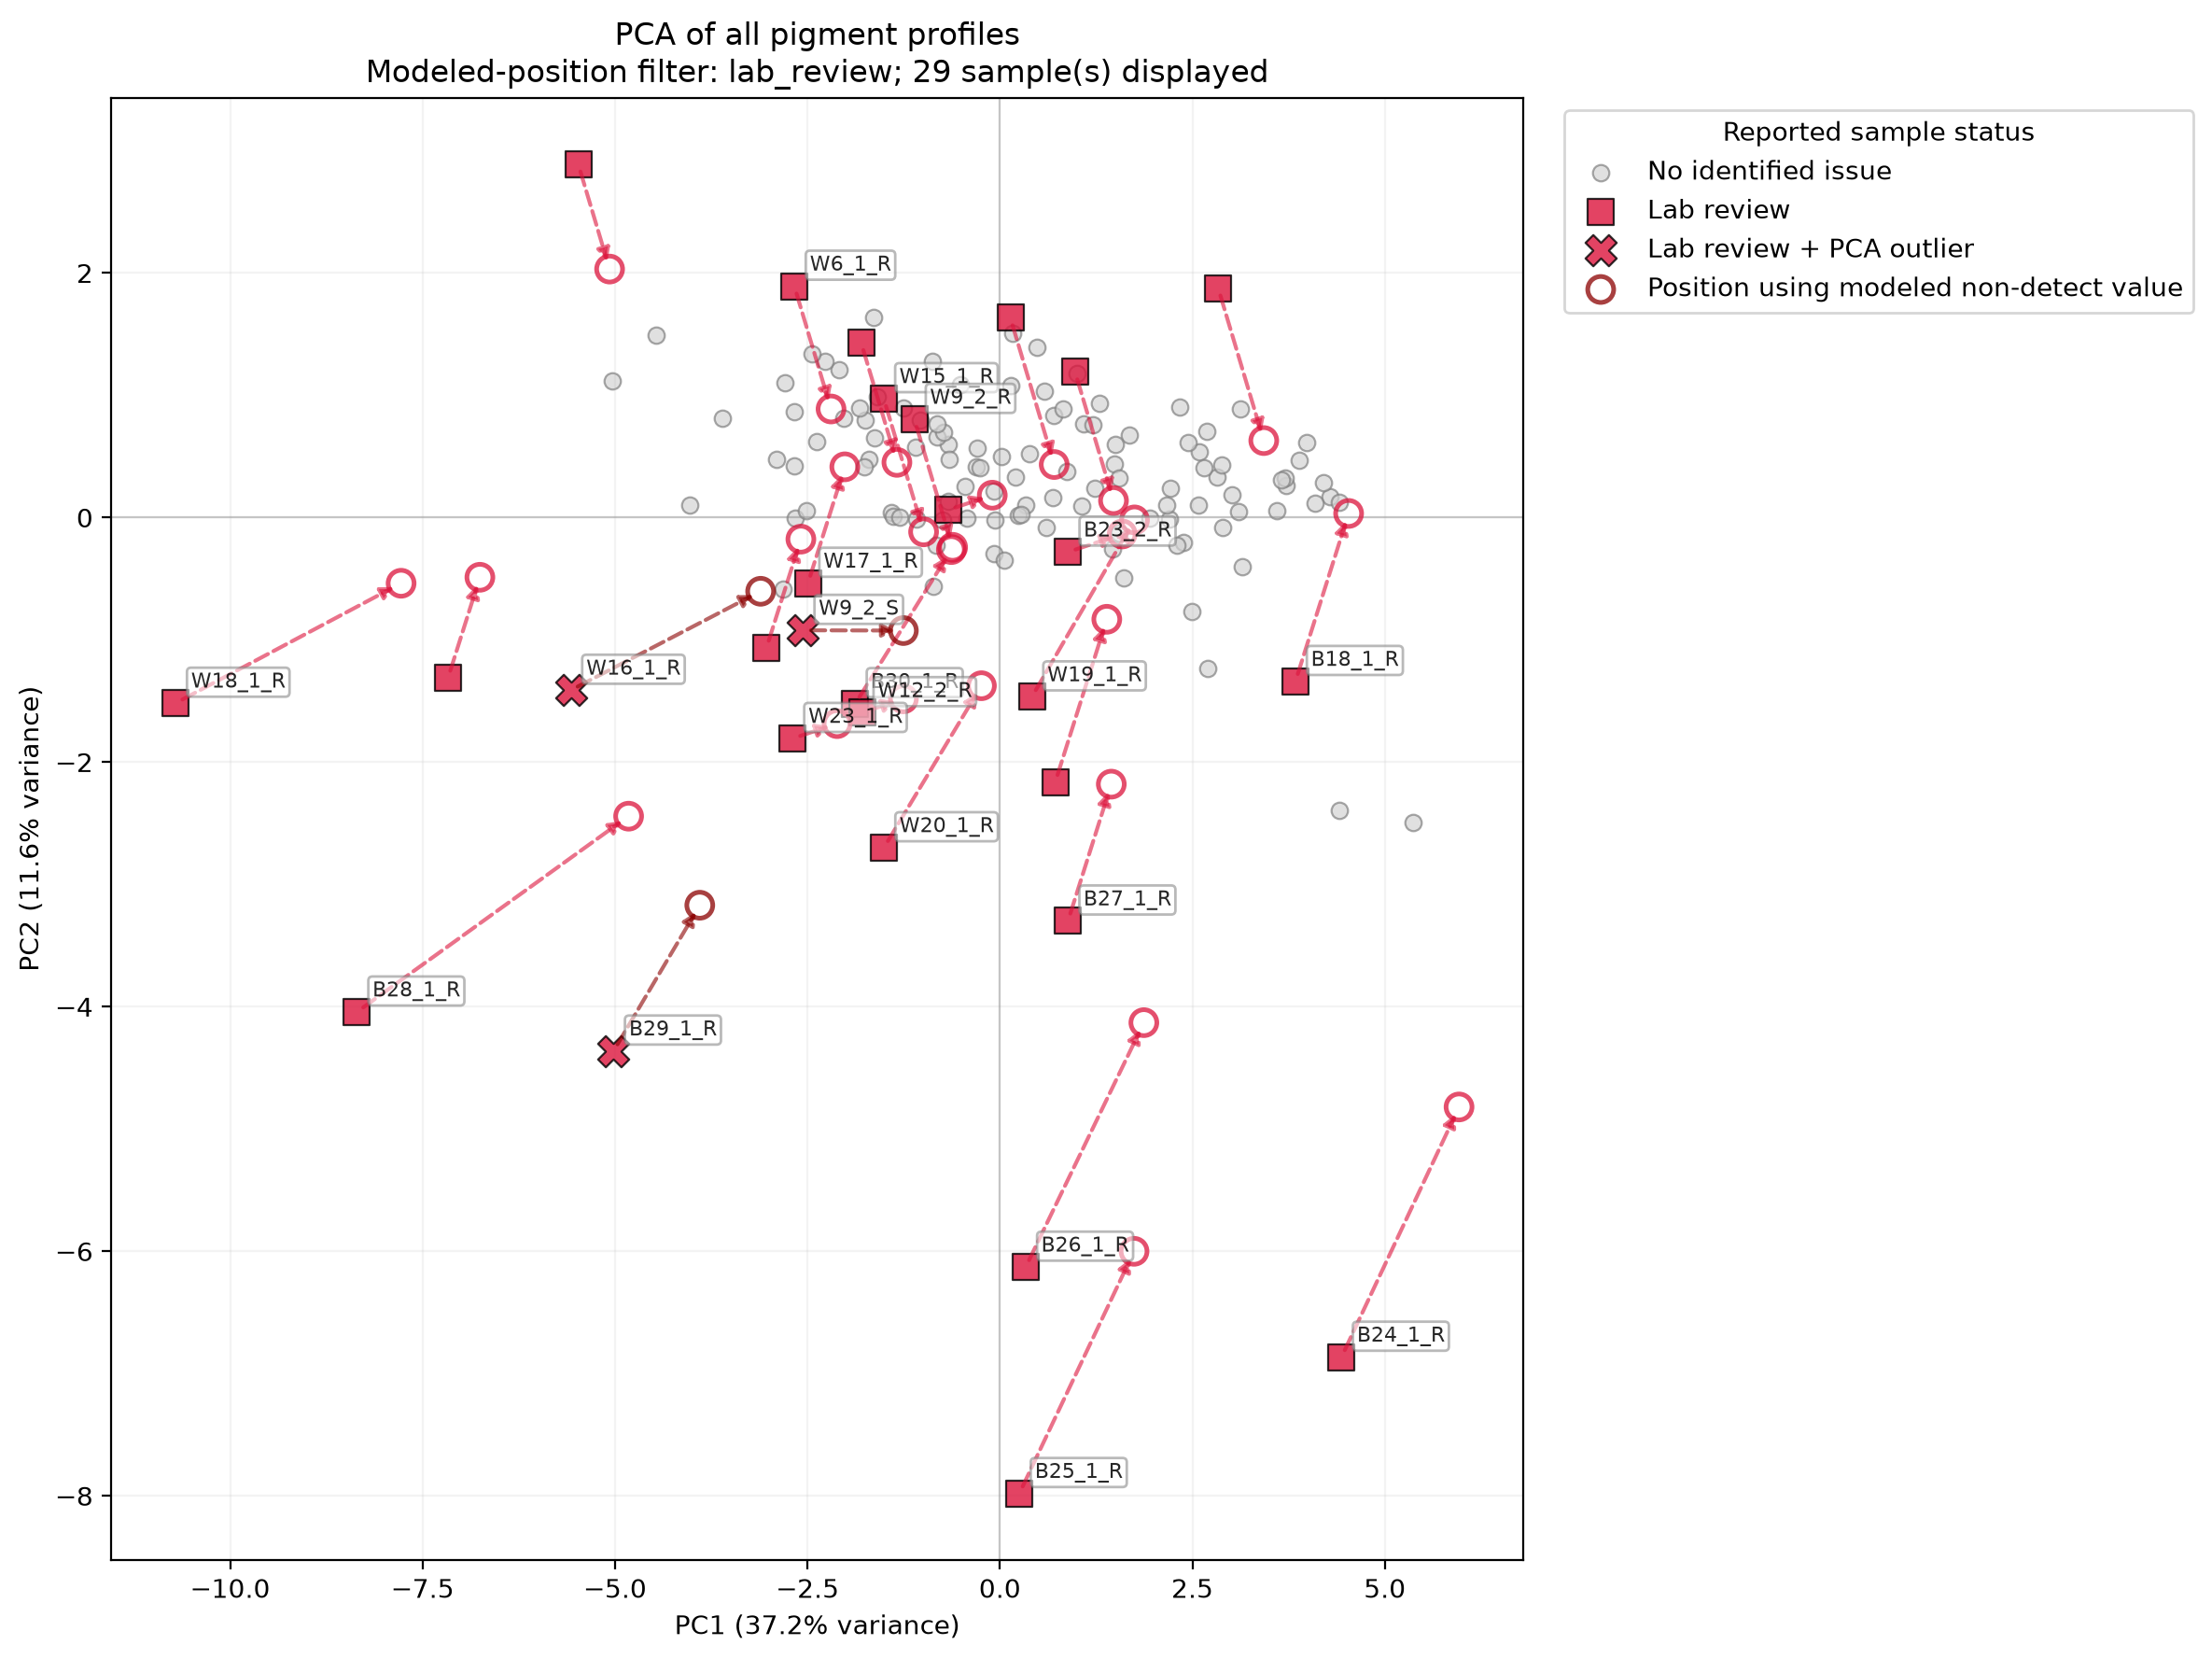

In [76]:
fig, ax = plot_pigment_pca_with_modeled_positions(
    pigment_pca_qc,
    x_component="PC1",
    y_component="PC2",
    modeled_position_filter="lab_review",
    background_alpha=0.70,
    highlighted_alpha=0.80,
    modeled_alpha=0.75,
    arrow_alpha=0.60,
    annotate=True,
    show_loadings=False,
)


In [77]:
# ============================================================
# CONSOLIDATED MAIN-PRIORITY NON-DETECT REPORT
# ============================================================

main_priority_report = (
    pigment_non_detect_qc["non_detect_assessment"]
    .loc[
        pigment_non_detect_qc["non_detect_assessment"]["review_priority"].isin(
            ["high", "medium"]
        )
    ]
    .copy()
)

priority_order = {
    "high": 0,
    "medium": 1,
}

main_priority_report["_priority_order"] = (
    main_priority_report["review_priority"].map(priority_order).fillna(99)
)

main_priority_report = main_priority_report.sort_values(
    [
        "_priority_order",
        "lab_review_recommended",
        "unexpected_non_detect",
        "model_cv_r2_log",
        "prediction_lower",
        "anomaly_percentile",
        "predicted_value",
    ],
    ascending=[
        True,
        False,
        False,
        False,
        False,
        False,
        False,
    ],
    na_position="last",
).drop(columns="_priority_order")

main_priority_report.insert(
    0,
    "priority_rank",
    np.arange(
        1,
        len(main_priority_report) + 1,
    ),
)

# Keep the most useful columns at the front.
main_columns = [
    "priority_rank",
    "pigment",
    "review_priority",
    "review_reason",
    "reported_value",
    "lab_review_recommended",
    "internal_review_recommended",
    "unexpected_non_detect",
    "moderate_model_evidence",
    "predicted_value",
    "prediction_lower",
    "prediction_upper",
    "model_cv_r2_log",
    "internal_model_is_reliable",
    "anomaly_percentile",
    "outside_normal_model_error",
    "n_other_quantifiable",
    "n_other_high",
    "high_other_pigments",
    "strong_pigment_context",
    "context_class",
]

main_columns = [
    column for column in main_columns if column in main_priority_report.columns
]

other_columns = [
    column for column in main_priority_report.columns if column not in main_columns
]

main_priority_report = main_priority_report[main_columns + other_columns]

print(
    "Number of main-priority non-detects:",
    len(main_priority_report),
)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(
        main_priority_report.style.format(
            {
                "predicted_value": "{:.2f}",
                "prediction_lower": "{:.2f}",
                "prediction_upper": "{:.2f}",
                "model_cv_r2_log": "{:.3f}",
                "anomaly_percentile": "{:.1f}",
            },
            na_rep="—",
        )
    )


Number of main-priority non-detects: 44


,,,priority_rank,pigment,review_priority,review_reason,reported_value,lab_review_recommended,internal_review_recommended,unexpected_non_detect,moderate_model_evidence,predicted_value,prediction_lower,prediction_upper,model_cv_r2_log,internal_model_is_reliable,anomaly_percentile,outside_normal_model_error,n_other_quantifiable,n_other_high,high_other_pigments,strong_pigment_context,context_class,interpretation,maximum_other_value,sum_other_quantifiable,context_priority,model_status,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,context_review_recommended
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
W16,1,R,1,Ddx (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,825.67,511.38,1332.74,0.777,True,100.0,True,14,1,Phta (ppb),False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,3121.105624,9615.890119,low,Model fitted,356.027328,True,True,True,False
B28,1,R,2,Lut (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,167.12,88.10,316.22,0.686,True,100.0,True,11,2,"Phtb (ppb), Phta (ppb)",False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,3321.078256,8727.737685,medium,Model fitted,112.448661,True,True,True,False
W18,1,R,3,Allo (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,27.33,11.32,64.18,0.678,True,100.0,True,9,0,,False,non_detect_with_other_quantifiable_pigments,Reported non-detect; assumed ≤ 10 ppb,4468.094333,5893.251210,informational,Model fitted,53.174575,True,True,True,False
W9,2,S,4,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,1986.73,731.08,5396.05,0.650,True,100.0,True,15,2,"Phtb (ppb), Phta (ppb)",False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,6885.921427,16910.419421,medium,Model fitted,1076.101996,True,True,True,False
W18,1,R,5,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,348.77,127.82,948.70,0.650,True,100.0,True,9,0,,False,non_detect_with_other_quantifiable_pigments,Reported non-detect; assumed ≤ 10 ppb,4468.094333,5893.251210,informational,Model fitted,1076.101996,True,True,True,False
B28,1,R,6,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,166.15,60.56,452.85,0.650,True,100.0,True,11,2,"Phtb (ppb), Phta (ppb)",False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,3321.078256,8727.737685,medium,Model fitted,1076.101996,True,True,True,False
B20,1,R,7,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,720.07,229.57,2254.05,0.623,True,100.0,True,17,8,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb), Echi (ppb), Phtb (ppb), Phta (ppb), Acar (ppb)",True,non_detect_with_strong_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,18312.323901,35942.332735,medium,Model fitted,350.363024,True,True,True,False
B15,1,R,8,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,595.49,189.73,1864.44,0.623,True,100.0,True,17,1,DVCh-a (ppb),False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,8565.854741,20545.988493,low,Model fitted,350.363024,True,True,True,False
W15,1,R,9,Chl_allo2 (ppb),high,Reliable model identifies a

In [78]:
display(pigment_non_detect_qc["lab_review"])


,,,pigment,reported_value,interpretation,n_other_quantifiable,n_other_high,maximum_other_value,sum_other_quantifiable,high_other_pigments,context_class,context_priority,...,strong_pigment_context,internal_review_recommended,review_priority,internal_model_is_reliable,context_review_recommended,review_reason,issue_type,severity,reason,observed_value
Station ID,Round,Sample Type,,,,,,,,,,,,,,,,,,,,,
W9,2,S,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,15.0,2.0,6885.921427,16910.419421,"Phtb (ppb), Phta (ppb)",non_detect_with_some_high_pigment_context,medium,...,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
W16,1,R,Ddx (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,14.0,1.0,3121.105624,9615.890119,Phta (ppb),non_detect_with_some_high_pigment_context,low,...,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
B20,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17.0,8.0,18312.323901,35942.332735,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb...",non_detect_with_strong_high_pigment_context,medium,...,True,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
B15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17.0,1.0,8565.854741,20545.988493,DVCh-a (ppb),non_detect_with_some_high_pigment_context,low,...,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
B26,1,R,Myxo (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,13.0,6.0,8682.495914,31041.183361,"Fuco (ppb), Allo (ppb), Zea (ppb), Chl_allo1 (...",non_detect_with_strong_high_pigment_context,medium,...,True,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
W15,1,R,Chl_allo2 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17.0,0.0,7869.286660,16526.760919,,non_detect_with_other_quantifiable_pigments,informational,...,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
B18,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,17.0,10.0,21065.882763,40627.809130,"Peri (ppb), Chlc2 (ppb), Fuco (ppb), Allo (ppb...",non_detect_with_strong_high_pigment_context,medium,...,True,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
W18,1,R,Chl_allo1 (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,9.0,0.0,4468.094333,5893.251210,,non_detect_with_other_quantifiable_pigments,informational,...,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN
W22,1,R,Acar (ppb),0.0,Reported non-detect; assumed ≤ 10 ppb,16.0,1.0,11408.313403,26177.744127,Phtb (ppb),non_detect_with_some_high_pigment_context,low,...,False,True,high,True,False,Reliable model identifies a strict unexpected ...,unexpected_non_detect,high,"Reported as a non-detect, but a reliable cross...",NaN


In [79]:
# Chlorophyll pigments and related derivatives present in PIGMENT_LIST
CHLOROPHYLL_RELATED_PIGMENTS = [
    "Chla",
    "DVCh-a",
    "Chlb",
    "Chlc2",
    "Chl_allo1",
    "Chl_allo2",
    "Phta",
    "Phtb",
]

chlorophyll_related_columns = [
    f"{pigment} ({chla_columns_orig_unit})" for pigment in CHLOROPHYLL_RELATED_PIGMENTS
]

chlorophyll_priority_report = main_priority_report.loc[
    main_priority_report["pigment"].isin(chlorophyll_related_columns)
].copy()

# Recalculate ranks within this chlorophyll-only subset
chlorophyll_priority_report = chlorophyll_priority_report.drop(
    columns="priority_rank",
    errors="ignore",
).reset_index(drop=False)

chlorophyll_priority_report.insert(
    0,
    "priority_rank",
    np.arange(
        1,
        len(chlorophyll_priority_report) + 1,
    ),
)

print(
    "Number of chlorophyll-related priority results:",
    len(chlorophyll_priority_report),
)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
):
    display(
        chlorophyll_priority_report.style.format(
            {
                "predicted_value": "{:.2f}",
                "prediction_lower": "{:.2f}",
                "prediction_upper": "{:.2f}",
                "model_cv_r2_log": "{:.3f}",
                "anomaly_percentile": "{:.1f}",
            },
            na_rep="—",
        )
    )


Number of chlorophyll-related priority results: 21


,priority_rank,Station ID,Round,Sample Type,pigment,review_priority,review_reason,reported_value,lab_review_recommended,internal_review_recommended,unexpected_non_detect,moderate_model_evidence,predicted_value,prediction_lower,prediction_upper,model_cv_r2_log,internal_model_is_reliable,anomaly_percentile,outside_normal_model_error,n_other_quantifiable,n_other_high,high_other_pigments,strong_pigment_context,context_class,interpretation,maximum_other_value,sum_other_quantifiable,context_priority,model_status,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,context_review_recommended
0,1,W9,2,S,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,1986.73,731.08,5396.05,0.650,True,100.0,True,15,2,"Phtb (ppb), Phta (ppb)",False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,6885.921427,16910.419421,medium,Model fitted,1076.101996,True,True,True,False
1,2,W18,1,R,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,348.77,127.82,948.70,0.650,True,100.0,True,9,0,,False,non_detect_with_other_quantifiable_pigments,Reported non-detect; assumed ≤ 10 ppb,4468.094333,5893.251210,informational,Model fitted,1076.101996,True,True,True,False
2,3,B28,1,R,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,166.15,60.56,452.85,0.650,True,100.0,True,11,2,"Phtb (ppb), Phta (ppb)",False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,3321.078256,8727.737685,medium,Model fitted,1076.101996,True,True,True,False
3,4,B20,1,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,720.07,229.57,2254.05,0.623,True,100.0,True,17,8,"Chlc2 (ppb), Myxo (ppb), Cant (ppb), Chla (ppb), Echi (ppb), Phtb (ppb), Phta (ppb), Acar (ppb)",True,non_detect_with_strong_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,18312.323901,35942.332735,medium,Model fitted,350.363024,True,True,True,False
4,5,B15,1,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,595.49,189.73,1864.44,0.623,True,100.0,True,17,1,DVCh-a (ppb),False,non_detect_with_some_high_pigment_context,Reported non-detect; assumed ≤ 10 ppb,8565.854741,20545.988493,low,Model fitted,350.363024,True,True,True,False
5,6,W15,1,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,384.42,122.24,1204.36,0.623,True,100.0,True,17,0,,False,non_detect_with_other_quantifiable_pigments,Reported non-detect; assumed ≤ 10 ppb,7869.286660,16526.760919,informational,Model fitted,350.363024,True,True,True,False
6,7,W23,2,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,331.08,105.19,1037.55,0.623,True,100.0,True,17,0,,False,non_detect_with_other_quantifiable_pigments,Reported non-detect; assumed ≤ 10 ppb,10727.291142,24145.307432,informational,Model fitted,350.363024,True,True,True,False
7,8,W9,2,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected non-detect: the conservative prediction is above the detection limit.,0.000000,True,True,True,True,323.84,102.87,1014.90,0.623,True,100.0,True,17,0,,False,non_detect_with_other_quantifiable_pigments,Reported non-detect; assumed ≤ 10 ppb,8061.362640,17486.545687,informational,Model fitted,350.363024,True,True,True,False
8,9,W6,1,R,Chl_allo2 (ppb),high,Reliable model identifies a 

In [80]:
chla_related_columns = [
    f"{pigment} ({chla_columns_orig_unit})" for pigment in chla_columns
]

chla_priority_report = main_priority_report.loc[
    main_priority_report["pigment"].isin(chla_related_columns)
].copy()

chla_priority_report = chla_priority_report.drop(
    columns="priority_rank",
    errors="ignore",
).reset_index(drop=False)

chla_priority_report.insert(
    0,
    "priority_rank",
    np.arange(
        1,
        len(chla_priority_report) + 1,
    ),
)

display(chla_priority_report)


,priority_rank,Station ID,Round,Sample Type,pigment,review_priority,review_reason,reported_value,lab_review_recommended,internal_review_recommended,...,interpretation,maximum_other_value,sum_other_quantifiable,context_priority,model_status,model_cv_mae,model_is_reliable,model_suggests_unexpected,materially_above_detection,context_review_recommended
0,1,W9,2,S,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,6885.921427,16910.419421,medium,Model fitted,1076.101996,True,True,True,False
1,2,W18,1,R,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,4468.094333,5893.251210,informational,Model fitted,1076.101996,True,True,True,False
2,3,B28,1,R,Chl_allo1 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,3321.078256,8727.737685,medium,Model fitted,1076.101996,True,True,True,False
3,4,B20,1,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,18312.323901,35942.332735,medium,Model fitted,350.363024,True,True,True,False
4,5,B15,1,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,8565.854741,20545.988493,low,Model fitted,350.363024,True,True,True,False
5,6,W15,1,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,7869.286660,16526.760919,informational,Model fitted,350.363024,True,True,True,False
6,7,W23,2,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,10727.291142,24145.307432,informational,Model fitted,350.363024,True,True,True,False
7,8,W9,2,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,8061.362640,17486.545687,informational,Model fitted,350.363024,True,True,True,False
8,9,W6,1,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,5765.567789,12892.704035,informational,Model fitted,350.363024,True,True,True,False
9,10,W6,2,R,Chl_allo2 (ppb),high,Reliable model identifies a strict unexpected ...,0.0,True,True,...,Reported non-detect; assumed ≤ 10 ppb,9549.682505,17008.050354,informational,Model fitted,350.363024,True,True,True,False


# END